# EAUI 2026 — Notebook consolidado

Pipeline completo de procesamiento, recodificación y análisis de la Encuesta de Acceso y Uso de Internet (SUBTEL 2026), seguido del modelo de predicción del **nivel de habilidades digitales** (SHAP).

Consolida los notebooks `eaui2026_v3.ipynb` (procesamiento) y `eaui2026_v5.ipynb` (predicción de habilidades). Se omitió `eaui2026_v4.ipynb` porque correspondía a la predicción de GSE.

**Orden de ejecución:** Carga → GSE → Etiquetas → NS/NR → Renombrado → Recodificaciones → Funciones → Habilidades digitales → Generador de gráficos → Modelo predictivo de habilidades (SHAP).

## 1. Carga del archivo

In [1]:
import pyreadstat
import re
import unicodedata
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import prince
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

df, meta = pyreadstat.read_sav("/Users/tomas/github/eaui_subtel/data/sav/2026.sav")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Filas: 5,000 | Columnas: 587


## 2. GSE derivado

Se calcula aquí con los nombres originales SPSS (`A10`, `A11`), antes de cualquier renombrado o recodificación.

In [2]:
def _educ_g(e):
    if pd.isna(e): return None
    e = int(e)
    if e <= 3:  return 'basica'
    if e <= 7:  return 'media'
    if e <= 9:  return 'tecnica'
    return 'universitaria'

_M = {
    (1,'basica'):'E',  (1,'media'):'E',  (1,'tecnica'):'D',  (1,'universitaria'):'D',
    (2,'basica'):'E',  (2,'media'):'D',  (2,'tecnica'):'D',  (2,'universitaria'):'C3',
    (3,'basica'):'D',  (3,'media'):'C3', (3,'tecnica'):'C3', (3,'universitaria'):'C2',
    (4,'basica'):'C3', (4,'media'):'C2', (4,'tecnica'):'C2', (4,'universitaria'):'C1',
    (5,'basica'):'C2', (5,'media'):'C1', (5,'tecnica'):'C1', (5,'universitaria'):'AB',
    (6,'basica'):'C1', (6,'media'):'AB', (6,'tecnica'):'AB', (6,'universitaria'):'AB',
}
_ORDEN_GSE = ['AB','C1','C2','C3','D','E']  # Invertido

_eg = df['A10'].apply(_educ_g)
df['gse'] = pd.Categorical(
    df['A11'].combine(_eg, lambda o, e: np.nan if pd.isna(o) or e is None else _M.get((int(o), e), np.nan)),
    categories=_ORDEN_GSE, ordered=True  # Aquí usa el orden invertido automáticamente
)
print('GSE:', df['gse'].value_counts().reindex(_ORDEN_GSE).to_dict())

GSE: {'AB': 342, 'C1': 533, 'C2': 988, 'C3': 1316, 'D': 833, 'E': 988}


## 3. Etiquetas limpias

Construye un diccionario `etiquetas_limpias` con la etiqueta útil de cada variable SPSS.
Usado en `analizar_rm()` y consultas.

In [3]:
def limpiar_etiqueta(label):
    """Extrae la parte descriptiva útil de una etiqueta SPSS."""
    if not label: return label
    label = label.strip()
    # Patrón B/C: empieza con código de variable (P3_1 .-, Q1.3.-)
    if re.match(r'^[A-Z]\w+[\._]\w+\s*\.-?', label):
        if ':' in label:
            r = label.split(':')[-1].strip()
            if r: return r
        if '?' in label:
            r = label.split('?')[-1].strip().lstrip(':').strip()
            if r: return r
        r = re.sub(r'^[A-Z]\w+[\._]\w+[\s\._\-]+', '', label).strip()
        return r.lstrip('.-').strip()
    # Patrón A: etiqueta + [pregunta padre] (corchete abre, cierre o no)
    if '[' in label:
        r = label[:label.index('[')].strip()
        return re.sub(r'^\d+[\.-]+\s*', '', r).strip()
    # Patrón D: numeración inicial
    return re.sub(r'^\d+[\.-]+\s*', '', label).strip()


etiquetas_limpias = {
    col: limpiar_etiqueta(label)
    for col, label in zip(meta.column_names, meta.column_labels) if label
}
print(f"Etiquetas procesadas: {len(etiquetas_limpias)}")

Etiquetas procesadas: 587


## 4. Diccionario de variables originales

In [4]:
diccionario = pd.DataFrame({'variable': meta.column_names, 'etiqueta': meta.column_labels})
diccionario.head(20)

,variable,etiqueta
0,REGISTRO,Número de registro
1,FECHAFIN,Fecha de fin de la entrevista
2,COD_REGION,Región
3,COMUNA_DEF,Comuna
4,ZONA,ZONA
5,A9,A9.- ¿Cuál es su parentesco con el Jefe /a de ...
6,A10,"A10.- Pensando en el jefe de hogar, ¿cuál fue ..."
7,A11,A11.- Y ¿Cuál es la profesión o trabajo o acti...
8,A12_11,Aymara [A12.- ¿Algún miembro de este hogar per...
9,A12_2,Rapa-Nui [A12.- ¿Algún miembro de este hogar p...


In [5]:
# Buscar variable por nombre o fragmento de etiqueta
busqueda = 'A10'
diccionario[
    diccionario['variable'].str.contains(busqueda, case=False) |
    diccionario['etiqueta'].str.contains(busqueda, case=False, na=False)
]

,variable,etiqueta
6,A10,"A10.- Pensando en el jefe de hogar, ¿cuál fue ..."


In [6]:
# Ver categorías codificadas de una variable
variable = 'Q13'
labels = meta.variable_value_labels.get(variable, {})
if labels:
    for k, v in labels.items(): print(f'  {k} -> {v}')
else:
    print(f"'{variable}' no tiene etiquetas de valor.")

  1.0 -> Banda Ancha Fija O Wifi [Adsl / Cable Modem / FibraÓptica / Wisp]
  2.0 -> Banda Ancha Móvil [Bam]
  3.0 -> Internet Móvil Con Plan O Bolsa De Gigas/Megas De Un Teléfono Móvil [Smartphone] / Tablet
  4.0 -> Conexión Satelital


## 5. Tratamiento NS/NR

Variables de montos usan `9999999` como código NS/NR.

In [7]:
cols_nsnr = [
    'P11','Q7_4',
    'P17_1','P17_2','P17_3','P17_4','P17_5',
    'P19_1','P19_2','P19_3','P19_4',
    'Q40_1','Q40_2','Q40_3','Q40_4','Q40_5',
    'Q42','Q42_1'
]
for col in cols_nsnr:
    if col in df.columns: df[col] = df[col].replace(9999999, np.nan)
print('NS/NR reemplazados por NaN.')

NS/NR reemplazados por NaN.


## 6. Renombrado de variables

Asigna nombres cortos a las variables principales. `educ_jh` y `ocupacion_jh` se recodifican
aquí, antes de la sección 7, porque el GSE ya fue calculado con sus valores numéricos.

In [8]:
nombres_cortos = {
    'REGISTRO':'id', 'FECHAFIN':'fecha_fin', 'COD_REGION':'region', 'COMUNA_DEF':'comuna', 'ZONA':'zona',
    'A9':'parentesco_jh', 'A10':'educ_jh', 'A11':'ocupacion_jh', 'A12_1':'ingreso_hogar',
    'Q1':'parentesco', 'Q1_1':'edad', 'Q1_2':'sexo', 'Q1_3':'educ', 'Q1_4':'ocupacion_encuestado', 'Q2':'actividad',
    'P1':'acceso_internet_hogar', 'P2':'n_smartphones_hogar', 'P2_1':'n_computadores_hogar',
    'P10':'tipo_acceso_fijo', 'P11':'pago_mensual_internet', 'P11_3':'velocidad_contratada',
    'P11_4':'calidad_acceso', 'P11_5':'cuota_mensual_gb', 'P12_2':'tipo_plan', 'P12_1':'plan_movil_tipo',
    'P14':'razon_no_acceso_principal', 'P15':'disposicion_contratar_fijo',
    'Q5':'uso_computador', 'Q7':'uso_smartphone', 'Q7_1':'smartphone_propio',
    'Q7_3':'plan_movil_tipo_ind', 'Q7_4':'pago_mensual_movil',
    'Q9':'ultimo_uso_internet', 'Q10':'frecuencia_internet', 'Q11':'tiempo_diario_internet',
    'Q13':'tipo_acceso_mas_usado', 'Q14':'uso_internet_hogar', 'Q15':'frecuencia_internet_hogar',
    'Q16':'tiempo_diario_hogar', 'Q17':'uso_internet_fuera_hogar', 'Q18':'frecuencia_fuera_hogar',
    'Q19':'tiempo_diario_fuera_hogar',
    'Q23':'internet_facilita_trabajo', 'Q25':'internet_mejora_vida', 'Q27':'ultima_compra_online',
    'Q31':'percepcion_proteccion', 'Q30_1':'reg_control_legal', 'Q30_2':'reg_control_familia', 'Q30_3':'reg_autocontrol',
    'FE_HOGAR':'fe_hogar', 'FE_PERSONAS':'fe_personas', 'POND_HOGAR':'pond_hogar', 'POND_PERSONAS':'pond_personas',
}

df = df.rename(columns={k: v for k, v in nombres_cortos.items() if k in df.columns})

# Recodificación de educ_jh y ocupacion_jh (aquí, con valores numéricos aún intactos)
_mapa_educ = {
    1:'Sin educación formal', 2:'Básica incompleta', 3:'Básica completa',
    4:'Media CH incompleta', 5:'Media TP incompleta', 6:'Media CH completa', 7:'Media TP completa',
    8:'Superior técnica incompleta', 9:'Superior técnica completa',
    10:'Superior universitaria incompleta', 11:'Superior universitaria completa'
}
_mapa_ocup = {
    1:'Trabajos ocasionales e informales', 2:'Oficio menor - obrero no calificado',
    3:'Obrero calificado - microempresario', 4:'Empleado medio - técnico - prof. independiente',
    5:'Ejecutivo medio - prof. universitario', 6:'Alto ejecutivo - empresario - directivo'
}
df['educ_jh']              = df['educ_jh'].map(_mapa_educ)
df['ocupacion_jh']         = df['ocupacion_jh'].map(_mapa_ocup)
df['ocupacion_encuestado'] = df['ocupacion_encuestado'].map({**_mapa_ocup, 7:'Sin trabajo remunerado'})

print(f"Renombradas: {len(nombres_cortos)} | Columnas totales: {df.shape[1]}")

Renombradas: 53 | Columnas totales: 588


## 7. Recodificaciones

Sobreescribe variables con valores en texto. Sin sufijos `_rec` ni `_label`.

In [9]:
df = df.copy()

# Identificación
df['region'] = df['region'].map({
    1:'Tarapacá', 2:'Antofagasta', 3:'Atacama', 4:'Coquimbo', 5:'Valparaíso',
    6:"O'Higgins", 7:'Maule', 8:'Biobío', 9:'Araucanía', 10:'Los Lagos',
    11:'Aysén', 12:'Magallanes', 13:'Metropolitana', 14:'Los Ríos', 15:'Arica y Parinacota', 16:'Ñuble'
})
df['zona'] = df['zona'].map({1:'Urbana', 2:'Rural'})

# Sociodemográficas del entrevistado
df['sexo'] = df['sexo'].map({1:'Hombre', 2:'Mujer'})
df['educ'] = df['educ'].map(_mapa_educ)
df['educ_grupo'] = df['educ'].map({
    'Sin educación formal':'Básica o menos', 'Básica incompleta':'Básica o menos',
    'Básica completa':'Básica o menos', 'Media CH incompleta':'Media',
    'Media TP incompleta':'Media', 'Media CH completa':'Media', 'Media TP completa':'Media',
    'Superior técnica incompleta':'Superior', 'Superior técnica completa':'Superior',
    'Superior universitaria incompleta':'Superior', 'Superior universitaria completa':'Superior',
})
df['tramo_edad'] = pd.cut(df['edad'], bins=[0,17,29,44,59,200],
                          labels=['Menor de 18','18-29','30-44','45-59','60 y más'], right=True)
df['actividad'] = df['actividad'].map({
    1:'Trabajador independiente', 2:'Empleador/patrón', 3:'Empleado dependiente',
    4:'Familiar no remunerado', 5:'FFAA y de orden', 6:'Cesante',
    7:'Jubilado/pensionado', 8:'Estudiante', 9:'Labores del hogar'
})

# Acceso a internet
df['acceso_internet_hogar'] = df['acceso_internet_hogar'].map({1:'Sí', 2:'No'})
df['tipo_acceso_fijo'] = df['tipo_acceso_fijo'].map({
    1:'ADSL', 2:'Cable/Módem', 3:'Fibra óptica', 4:'Inalámbrica',
    5:'Satelital', 31:'WiFi', 32:'Antena', 33:'Banda ancha', 34:'Acceso telefónico', 88:'No sabe'
})
df['velocidad_contratada'] = df['velocidad_contratada'].map({
    1:'Hasta 10 Mbps', 2:'Más de 10 a 100 Mbps', 3:'Más de 100 a 500 Mbps',
    4:'Más de 500 Mbps a 1 Gbps', 5:'Más de 1 Gbps', 99:'NS/NR'
})
df['tipo_plan'] = df['tipo_plan'].map({
    1:'Banda ancha desnuda', 2:'BA + TV Cable', 3:'BA + Telefonía fija',
    4:'Triple pack (BA+TV+Tel)', 5:'Otros planes'
})
df['tipo_acceso_mas_usado'] = df['tipo_acceso_mas_usado'].map({
    1.0:'Banda Ancha Fija / WiFi', 2.0:'Banda Ancha Móvil',
    3.0:'Internet Móvil (Smartphone/Tablet)', 4.0:'Conexión Satelital'
})

# Uso individual
df['uso_computador']  = df['uso_computador'].map({1:'Sí', 2:'No'})
df['uso_smartphone']  = df['uso_smartphone'].map({1:'Sí', 2:'No'})
df['ultimo_uso_internet'] = df['ultimo_uso_internet'].map({
    1:'Hoy', 2:'Entre 2 y 3 días', 3:'Entre 3 y 7 días', 4:'Entre 1 y 4 semanas',
    5:'Más de 4 semanas', 6:'Más de 12 meses', 7:'Nunca'
})
df['frecuencia_internet'] = df['frecuencia_internet'].map({
    1:'Todos los días', 2:'Varias veces por semana',
    3:'Al menos una vez al mes', 4:'Menos de una vez al mes'
})
df['tiempo_diario_internet'] = df['tiempo_diario_internet'].map({
    1:'Menos de 1 hora', 2:'Entre 1 y 2 horas', 3:'Entre 2 y 4 horas', 4:'Más de 4 horas'
})

# Percepciones
df['percepcion_proteccion']     = df['percepcion_proteccion'].map({
    1:'Muy protegido', 2:'Protegido', 3:'Desprotegido', 4:'Muy desprotegido', 99:'NS/NR'
})
df['internet_mejora_vida']      = df['internet_mejora_vida'].map({1:'Sí', 2:'No'})
df['internet_facilita_trabajo'] = df['internet_facilita_trabajo'].map({1:'Sí', 2:'No'})

print('Recodificaciones completadas.')
print(f"sexo: {df['sexo'].value_counts().to_dict()}")
print(f"acceso: {df['acceso_internet_hogar'].value_counts().to_dict()}")

Recodificaciones completadas.
sexo: {'Mujer': 2815, 'Hombre': 2185}
acceso: {'Sí': 4841, 'No': 159}


## 8. Ingreso del hogar

Los rangos varían según el tamaño del hogar. Se unifica calculando el punto medio de cada rango.

In [10]:
_rangos = {
    11:(0,129000),12:(130000,226000),13:(227000,393000),14:(394000,686000),15:(687000,1100000),16:(1200000,2000000),17:(2100000,None),
    21:(0,210000),22:(211000,366000),23:(367000,639000),24:(640000,1100000),25:(1200000,1900000),26:(2000000,3300000),27:(3400000,None),
    31:(0,279000),32:(280000,487000),33:(488000,849000),34:(850000,1400000),35:(1500000,2500000),36:(2600000,4500000),37:(4600000,None),
    41:(0,341000),42:(342000,595000),43:(596000,1000000),44:(1100000,1800000),45:(1900000,3100000),46:(3200000,5500000),47:(5600000,None),
    51:(0,399000),52:(400000,696000),53:(697000,1200000),54:(1300000,2100000),55:(2200000,3600000),56:(3700000,6400000),57:(6500000,None),
    61:(0,453000),62:(454000,791000),63:(792000,1300000),64:(1400000,2400000),65:(2500000,4100000),66:(4200000,7300000),67:(7400000,None),
    71:(0,505000),72:(506000,881000),73:(882000,1500000),74:(1600000,2600000),75:(2700000,4600000),76:(4700000,8100000),77:(8200000,None),
    81:(0,555000),82:(556000,967000),83:(968000,1600000),84:(1700000,2900000),85:(3000000,5100000),86:(5200000,8900000),87:(9000000,None),
    91:(0,602000),92:(603000,1000000),93:(1100000,1800000),94:(1900000,3100000),95:(3200000,5500000),96:(5600000,9700000),97:(9800000,None),
    101:(0,648000),102:(649000,1100000),103:(1200000,1900000),104:(2000000,3400000),105:(3500000,5900000),106:(6000000,10400000),107:(10500000,None),
}
_mapa_pm = {float(k): (v[0]*1.5 if v[1] is None else (v[0]+v[1])/2) for k, v in _rangos.items()}

df['ingreso_pm'] = df['ingreso_hogar'].map(_mapa_pm)
df['ingreso_tramo'] = pd.cut(
    df['ingreso_pm'],
    bins=[0, 384000, 540000, 798000, 1100000, 1700000, float('inf')],
    labels=['Hasta $384 mil','$384 mil a $540 mil','$540 mil a $798 mil',
            '$798 mil a $1,1 millón','$1,1 millón a $1,7 millones','Más de $1,7 millones'],
    right=True
)
df['ingreso_grupo'] = df['ingreso_tramo'].map({
    'Hasta $384 mil':'Bajo', '$384 mil a $540 mil':'Bajo',
    '$540 mil a $798 mil':'Medio', '$798 mil a $1,1 millón':'Medio',
    '$1,1 millón a $1,7 millones':'Alto', 'Más de $1,7 millones':'Alto',
})

# Validación: promedio de ingreso debe subir de E a AB
(
    df.groupby('gse', observed=True)['ingreso_pm']
    .agg(N='count', Promedio='mean').reindex(_ORDEN_GSE).round(0).astype({'N':int,'Promedio':int})
)

,N,Promedio
gse,,
AB,286,2097505
C1,444,1389884
C2,826,986176
C3,1112,799533
D,704,650022
E,846,539833


## 9. Funciones de análisis ponderado

In [11]:
ORDEN_CATEGORIAS = {
    'sexo':         ['Hombre','Mujer'],
    'zona':         ['Urbana','Rural'],
    'region':       ['Tarapacá','Antofagasta','Atacama','Coquimbo','Valparaíso',"O'Higgins",'Maule',
                     'Biobío','Araucanía','Los Lagos','Aysén','Magallanes','Metropolitana',
                     'Los Ríos','Arica y Parinacota','Ñuble'],
    'educ':         ['Sin educación formal','Básica incompleta','Básica completa',
                     'Media CH incompleta','Media TP incompleta','Media CH completa','Media TP completa',
                     'Superior técnica incompleta','Superior técnica completa',
                     'Superior universitaria incompleta','Superior universitaria completa'],
    'educ_grupo':   ['Básica o menos','Media','Superior'],
    'tramo_edad':   ['Menor de 18','18-29','30-44','45-59','60 y más'],
    'actividad':    ['Trabajador independiente','Empleador/patrón','Empleado dependiente',
                     'Familiar no remunerado','FFAA y de orden','Cesante',
                     'Jubilado/pensionado','Estudiante','Labores del hogar'],
    'ocupacion_jh': ['Trabajos ocasionales e informales','Oficio menor - obrero no calificado',
                     'Obrero calificado - microempresario','Empleado medio - técnico - prof. independiente',
                     'Ejecutivo medio - prof. universitario','Alto ejecutivo - empresario - directivo'],
    'ocupacion_encuestado': ['Trabajos ocasionales e informales','Oficio menor - obrero no calificado',
                     'Obrero calificado - microempresario','Empleado medio - técnico - prof. independiente',
                     'Ejecutivo medio - prof. universitario','Alto ejecutivo - empresario - directivo',
                     'Sin trabajo remunerado'],
    'gse':              ['AB', 'C1', 'C2', 'C3', 'D', 'E'],
    'ingreso_tramo':    ['Hasta $384 mil','$384 mil a $540 mil','$540 mil a $798 mil',
                         '$798 mil a $1,1 millón','$1,1 millón a $1,7 millones','Más de $1,7 millones'],
    'ingreso_grupo':    ['Bajo','Medio','Alto'],
    'acceso_internet_hogar':    ['Sí','No'],
    'uso_computador':           ['Sí','No'],
    'uso_smartphone':           ['Sí','No'],
    'internet_mejora_vida':     ['Sí','No'],
    'internet_facilita_trabajo':['Sí','No'],
    'tipo_acceso_fijo':         ['Fibra óptica','Cable/Módem','ADSL','Inalámbrica','Satelital','WiFi','Antena','Banda ancha','Acceso telefónico','No sabe'],
    'tipo_acceso_mas_usado':    ['Banda Ancha Fija / WiFi','Banda Ancha Móvil','Internet Móvil (Smartphone/Tablet)','Conexión Satelital'],
    'tipo_plan':                ['Banda ancha desnuda','BA + TV Cable','BA + Telefonía fija','Triple pack (BA+TV+Tel)','Otros planes'],
    'ultimo_uso_internet':      ['Hoy','Entre 2 y 3 días','Entre 3 y 7 días',
                                  'Entre 1 y 4 semanas','Más de 4 semanas','Más de 12 meses','Nunca'],
    'frecuencia_internet':      ['Todos los días','Varias veces por semana',
                                  'Al menos una vez al mes','Menos de una vez al mes'],
    'tiempo_diario_internet':   ['Menos de 1 hora','Entre 1 y 2 horas','Entre 2 y 4 horas','Más de 4 horas'],
    'percepcion_proteccion':    ['Muy protegido','Protegido','Desprotegido','Muy desprotegido','NS/NR'],
    'velocidad_contratada':     ['Hasta 10 Mbps','Más de 10 a 100 Mbps','Más de 100 a 500 Mbps',
                                  'Más de 500 Mbps a 1 Gbps','Más de 1 Gbps','NS/NR'],
}


def fordf(df_tabla, titulo=None):
    """Formato visual: enteros sin decimales, porcentajes con 1 decimal."""
    
    # 1. Identificar solo las columnas que son numéricas
    num_cols = df_tabla.select_dtypes(include=['number']).columns
    
    # 2. Aplicar el formato solo a esas columnas
    estilo = df_tabla.style.format({
        col: '{:,.0f}' if 'ponderado' in str(col).lower() or 'total' in str(col).lower() or str(col).startswith('n ') else '{:.1f}'
        for col in num_cols
    })
    
    if titulo: 
        estilo = estilo.set_caption(titulo)
        
    return estilo




def _ordenar(df_res, var, cruzada=False):
    if var not in ORDEN_CATEGORIAS: return df_res
    orden = ORDEN_CATEGORIAS[var]
    if cruzada:
        ok  = [v for v in orden if v in df_res.index]
        rst = [v for v in df_res.index if v not in ok and v != 'Total']
        fin = ok + rst + (['Total'] if 'Total' in df_res.index else [])
        return df_res.reindex(fin)
    ok  = [v for v in orden if v in df_res[var].values]
    rst = [v for v in df_res[var].values if v not in ok and v != 'Total']
    df_res[var] = pd.Categorical(df_res[var], categories=ok+rst+['Total'], ordered=True)
    return df_res.sort_values(var).reset_index(drop=True)


def dstats(data_df, variables, tipo='frecuencia', cruce=None, factor=None, transponer=False, estilo=True):
    """
    Análisis ponderado de variables simples.
    tipo: 'frecuencia' | 'cruzada' | 'promedio' | 'suma'
    Si estilo=True, retorna Styler formateado. Si es False, retorna el DataFrame puro.
    Ejemplo: dstats(df, 'sexo', tipo='frecuencia', factor='fe_personas', estilo=False)
    """
    if isinstance(variables, str): variables = [variables]
    for col in variables + [factor] + ([cruce] if cruce else []):
        if col not in data_df.columns:
            raise ValueError(f"Columna '{col}' no existe.")

    if tipo == 'frecuencia':
        var = variables[0]
        tot = data_df[factor].sum()
        res = data_df.groupby(var, observed=True)[factor].sum().reset_index().rename(columns={factor:'n_ponderado'})
        res['porcentaje'] = (res['n_ponderado'] / tot * 100).round(2)
        res = pd.concat([res, pd.DataFrame({var:['Total'],'n_ponderado':[res['n_ponderado'].sum()],'porcentaje':[res['porcentaje'].sum().round(2)]})], ignore_index=True)
        res = _ordenar(res, var).set_index(var)
        
        if estilo:
            titulo = f"Frecuencia: '{var}' — base ponderada: {tot:,.0f} ({factor})"
            return fordf(res, titulo=titulo)
        return res

    if tipo == 'cruzada':
        var = variables[0]
        tot = data_df[factor].sum()
        t   = data_df.pivot_table(values=factor, index=var, columns=cruce, aggfunc='sum', fill_value=0, observed=False)
        tp  = t.div(t.sum(axis=0), axis=1).mul(100).round(2)
        if var in ORDEN_CATEGORIAS:
            of = [v for v in ORDEN_CATEGORIAS[var] if v in t.index];  t, tp = t.reindex(of), tp.reindex(of)
        if cruce in ORDEN_CATEGORIAS:
            oc = [v for v in ORDEN_CATEGORIAS[cruce] if v in t.columns]; t, tp = t[oc], tp[oc]
        if transponer: t, tp = t.T, tp.T
        t.loc['Total'], tp.loc['Total'] = t.sum(numeric_only=True), tp.sum(numeric_only=True).round(2)
        cols = [s for c in t.columns for s in [t[c].rename(f'n {c}'), tp[c].rename(f'% {c}')]]
        res = pd.concat(cols, axis=1)
        
        if estilo:
            titulo = f"Cruce: '{var}' según '{cruce}' — base ponderada: {tot:,.0f} ({factor})"
            return fordf(res, titulo=titulo)
        return res

    def _wavg(sub, v, f):
        d = sub[[v, f]].dropna()
        return float(round(np.average(d[v], weights=d[f]), 4)) if len(d) > 0 and d[f].sum() > 0 else np.nan

    def _wsum(sub, v, f):
        d = sub[[v, f]].dropna()
        return float(round((d[v]*d[f]).sum(), 4))

    fn = _wavg if tipo == 'promedio' else _wsum
    col_name = 'promedio_ponderado' if tipo == 'promedio' else 'suma_ponderada'

    if not cruce:
        res = pd.DataFrame([(v, fn(data_df, v, factor)) for v in variables], columns=['variable', col_name])
        
        if estilo:
            titulo = f"{tipo.capitalize()} de variables — factor: {factor}"
            return fordf(res, titulo=titulo)
        return res

    filas = {g: {v: fn(sg, v, factor) for v in variables} for g, sg in data_df.groupby(cruce, observed=True)}
    filas['Total'] = {v: fn(data_df, v, factor) for v in variables}
    res = pd.DataFrame(filas).T
    res.index.name = cruce
    if cruce in ORDEN_CATEGORIAS:
        ok  = [v for v in ORDEN_CATEGORIAS[cruce] if v in res.index]
        rst = [v for v in res.index if v not in ok and v != 'Total']
        res = res.reindex(ok + rst + ['Total'])
        
    if estilo:
        titulo = f"{tipo.capitalize()} cruzado por '{cruce}' — factor: {factor}"
        return fordf(res, titulo=titulo)
    return res


print('ORDEN_CATEGORIAS, fordf, dstats listos.')

ORDEN_CATEGORIAS, fordf, dstats listos.


## 10. Grupos de respuesta múltiple

In [12]:
_c = df.columns

GRUPOS_RM = {
    # Hogar
    'A12':  ('Pueblos indígenas o tribales (hogar)',            [c for c in _c if c.startswith('A12_') and not c.startswith('A12_1')]),
    'A13':  ('Condiciones permanentes de salud en el hogar',   [c for c in _c if c.startswith('A13_')]),
    'A14':  ('Situaciones laborales en el hogar',              [c for c in _c if c.startswith('A14_') and not c.endswith('_OTRA')]),
    # Acceso y conectividad
    'P3':   ('Dispositivos usados para acceder a internet',    [c for c in _c if c.startswith('P3_') and not c.endswith('_OTRA')]),
    'P4':   ('Formas de acceso pagado a internet en el hogar', [c for c in _c if c.startswith('P4_')]),
    'P6':   ('Razones para tener internet fijo',               [c for c in _c if c.startswith('P6_') and not c.startswith('P6_1_') and not c.endswith('_OTRA')]),
    'P6_1': ('Razones para tener internet móvil',              [c for c in _c if c.startswith('P6_1_')]),
    'P7':   ('Medidas de protección internet para menores',    [c for c in _c if c.startswith('P7_')]),
    'P9':   ('Dispositivos de uso personal de menores',        [c for c in _c if c.startswith('P9_')]),
    'P12':  ('Conexión móvil 4G/5G',                           ['P12_11','P12_21','P12_31','P12_41']),
    'P13':  ('Razones de no acceso a internet fijo',           [c for c in _c if c.startswith('P13_') and not c.endswith('_OTRA')]),
    'P16':  ('Equipos que le interesaría tener (sin internet)',[c for c in _c if c.startswith('P16_')]),
    # Uso individual
    'Q6':   ('¿Cómo aprendió a usar el computador?',           [c for c in _c if c.startswith('Q6_') and c not in ['Q6_1','Q6_OTRA']]),
    'Q7_2': ('Smartphone 4G/5G',                               ['Q7_2_1','Q7_2_2','Q7_2_3','Q7_2_4']),
    'Q8':   ('Habilidades digitales',                          [c for c in _c if c.startswith('Q8_')]),
    'Q11_1':('Lugares donde usó internet ayer',                [c for c in _c if c.startswith('Q11_1_')]),
    'Q12':  ('Tipos de acceso en últimos 3 meses',             [c for c in _c if c.startswith('Q12_')]),
    'Q20':  ('Lugares donde usó internet fuera del hogar',     [c for c in _c if c.startswith('Q20_')]),
    'Q21':  ('Actividades realizadas en internet',             [c for c in _c if c.startswith('Q21_') and c not in ['Q21_1','Q21_10','Q21_19','Q21_26','Q21_33','Q21_38','Q21_44']]),
    'Q28':  ('Bienes y servicios comprados en internet',       [c for c in _c if c.startswith('Q28_') and not c.endswith('_OTRA')]),
    'Q32':  ('Actividades de seguridad y privacidad',          [c for c in _c if c.startswith('Q32_') and not c.endswith('_OTRA')]),
    'Q33':  ('Problemas de seguridad sufridos',                [c for c in _c if c.startswith('Q33_') and not c.endswith('_OTRA')]),
    'Q34':  ('Razones de no uso de internet',                  [c for c in _c if c.startswith('Q34_') and not c.endswith('_OTRA')]),
    'Q37':  ('Actividades de internet realizadas por terceros',[c for c in _c if c.startswith('Q37_')]),
    'Q39':  ('Equipos que le interesaría tener (no usuarios)', [c for c in _c if c.startswith('Q39_')]),
}

def analizar_rm(grupo, factor='fe_hogar', top_n=None, estilo=True):
    """
    Analiza un grupo de respuesta múltiple.
    Si estilo=True, retorna tabla estilizada (HTML). Si es False, retorna el DataFrame puro.
    """
    if grupo not in GRUPOS_RM: 
        raise ValueError(f"Grupo '{grupo}' no existe.")
        
    desc, cols = GRUPOS_RM[grupo]
    cols = [c for c in cols if c in df.columns]
    base = df.loc[df[cols].notna().any(axis=1), factor].sum()
    
    filas = [
        {'variable': c,
         'etiqueta': etiquetas_limpias.get(c, c),
         'n_ponderado': int(df.loc[df[c]==1, factor].sum()),
         'porcentaje': round(df.loc[df[c]==1, factor].sum() / base * 100, 1)}
        for c in cols
    ]
    res = pd.DataFrame(filas).sort_values('porcentaje', ascending=False).reset_index(drop=True)
    if top_n: res = res.head(top_n)
    res.index += 1
    
    if estilo:
        titulo_tabla = f"{desc} — base ponderada: {int(base):,} ({factor})"
        return fordf(res, titulo=titulo_tabla)
    return res

print("Grupos de respuesta múltiple disponibles:")
for k, (desc, cols) in GRUPOS_RM.items():
    cols_validas = [c for c in cols if c in df.columns]
    print(f"  '{k}': {desc} ({len(cols_validas)} opciones)")

Grupos de respuesta múltiple disponibles:
  'A12': Pueblos indígenas o tribales (hogar) (8 opciones)
  'A13': Condiciones permanentes de salud en el hogar (7 opciones)
  'A14': Situaciones laborales en el hogar (8 opciones)
  'P3': Dispositivos usados para acceder a internet (8 opciones)
  'P4': Formas de acceso pagado a internet en el hogar (5 opciones)
  'P6': Razones para tener internet fijo (13 opciones)
  'P6_1': Razones para tener internet móvil (13 opciones)
  'P7': Medidas de protección internet para menores (12 opciones)
  'P9': Dispositivos de uso personal de menores (4 opciones)
  'P12': Conexión móvil 4G/5G (4 opciones)
  'P13': Razones de no acceso a internet fijo (29 opciones)
  'P16': Equipos que le interesaría tener (sin internet) (5 opciones)
  'Q6': ¿Cómo aprendió a usar el computador? (12 opciones)
  'Q7_2': Smartphone 4G/5G (4 opciones)
  'Q8': Habilidades digitales (19 opciones)
  'Q11_1': Lugares donde usó internet ayer (9 opciones)
  'Q12': Tipos de acceso en últ

In [13]:
def analizar_rm_cruce(grupo, cruce, factor='fe_personas', estilo=True):
    """
    Analiza un grupo de respuesta múltiple cruzado por una variable demográfica.
    Si estilo=True, retorna tabla estilizada (HTML). Si es False, retorna el DataFrame puro.
    """
    if grupo not in GRUPOS_RM: 
        raise ValueError(f"Grupo '{grupo}' no existe.")
        
    desc, cols = GRUPOS_RM[grupo]
    cols = [c for c in cols if c in df.columns]
    
    base_cruce = df.loc[df[cols].notna().any(axis=1)].groupby(cruce, observed=True)[factor].sum()
    
    resultados = {}
    for categoria in base_cruce.index:
        base = base_cruce[categoria]
        df_cat = df[df[cruce] == categoria]
        
        pcts = {
            etiquetas_limpias.get(c, c): round((df_cat.loc[df_cat[c]==1, factor].sum() / base) * 100, 1) 
            if base > 0 else 0 
            for c in cols
        }
        resultados[categoria] = pcts
        
    res_df = pd.DataFrame(resultados)
    res_df = res_df.sort_values(by=res_df.columns[0], ascending=False)
    
    if estilo:
        titulo_tabla = f"{desc} cruzado por '{cruce}' — factor: {factor}"
        return fordf(res_df, titulo=titulo_tabla)
    return res_df

In [14]:
analizar_rm('Q8', factor='fe_personas')

,variable,etiqueta,n_ponderado,porcentaje
1,Q8_12,"Revisar redes sociales (Facebook, Instagram, Whatapps, Youtube, TikTok, etc)","11,282,482",84.9
2,Q8_15,Realizar videollamdas,"11,271,083",84.8
3,Q8_16,Enviar y recibir correos con o sin archivos adjuntos,"9,780,624",73.6
4,Q8_17,"Realizar transacciones bancarias, compras y pagos en línea","9,529,520",71.7
5,Q8_14,Editar fotografías o videos,"8,213,889",61.8
6,Q8_1,Uso de procesador de texto (ej: Word),"7,898,264",59.4
7,Q8_13,Subir contenidos o realizar posteos en redes sociales,"7,666,711",57.7
8,Q8_4,"Duplicar o transferir archivos entre dispositivos (cámaras digitales, celulares, reproductores de música) o en la nube","7,115,863",53.6
9,Q8_10,"Conectarme a sitios o aplicaciones para ver videos, series y película o escuchar música","7,043,538",53.0
10,Q8_5,"Conectar un nuevo dispositivo (como un router, cámara o impresora)","7,012,591",52.8


## 11. Habilidades digitales Q8 — clasificación por nivel

In [15]:
# Clasificación de habilidades Q8 por nivel de dificultad
# Criterio: nivel más alto alcanzado (jerárquico)
#
# Básico     — consumo y comunicación cotidiana (6 ítems)
# Intermedio — productividad, gestión y creación (9 ítems)
# Avanzado   — configuración técnica y programación (3 ítems)

Q8_BASICO = {
    'Q8_10': 'Streaming (video/música)',
    'Q8_11': 'Juegos en línea',
    'Q8_12': 'Revisar redes sociales',
    'Q8_13': 'Publicar en redes sociales',
    'Q8_15': 'Videollamadas',
    'Q8_16': 'Correo electrónico',
}
Q8_INTERMEDIO = {
    'Q8_1':  'Procesador de texto (Word)',
    'Q8_2':  'Planilla de cálculo (Excel)',
    'Q8_3':  'Presentaciones (PowerPoint)',
    'Q8_4':  'Transferir archivos / nube',
    'Q8_5':  'Conectar nuevo dispositivo',
    'Q8_6':  'Instalar y configurar apps',
    'Q8_14': 'Editar fotos o videos',
    'Q8_17': 'Transacciones y pagos en línea',
    'Q8_18': 'Uso de IA (ChatGPT, etc.)',
}
Q8_AVANZADO = {
    'Q8_7': 'Configurar seguridad del dispositivo',
    'Q8_8': 'Instalar SO / programar (Python, Java…)',
    'Q8_9': 'Crear un sitio web',
}

_cols_b  = list(Q8_BASICO)
_cols_i  = list(Q8_INTERMEDIO)
_cols_a  = list(Q8_AVANZADO)
_cols_q8 = _cols_b + _cols_i + _cols_a + ['Q8_19']

def _nivel(row):
    if row[_cols_a].eq(1).any():  return 'Avanzado'
    if row[_cols_i].eq(1).any():  return 'Intermedio'
    if row[_cols_b].eq(1).any():  return 'Básico'
    return 'Sin habilidades'

# Crear nivel_habilidades en df (5 000 filas)
# Quienes no respondieron Q8 caen en 'Sin habilidades' (eq(1) es False para NaN)
df['nivel_habilidades'] = df.apply(_nivel, axis=1)
mask_q8 = df[_cols_q8].notna().any(axis=1)  # máscara para la tabla de ítems Q8
base_q8 = int(mask_q8.sum())

# Distribución sin ponderar (descriptiva)
orden_nivel = ['Avanzado', 'Intermedio', 'Básico', 'Sin habilidades']
dist = df['nivel_habilidades'].value_counts().reindex(orden_nivel)
print(f"Base: {len(df):,} (total df) | respondentes Q8: {base_q8:,}\n")
print("Distribución (sin ponderar):")
for niv, n in dist.items():
    pct = n / len(df) * 100
    print(f"  {niv:<20} {n:>5,}  ({pct:.1f}%)")

# Tabla de habilidades por nivel (base: respondentes Q8)
print("\n── Habilidades por nivel ──────────────────────────────────────────────")
for nivel, items in [('BÁSICO', Q8_BASICO), ('INTERMEDIO', Q8_INTERMEDIO), ('AVANZADO', Q8_AVANZADO)]:
    print(f"\n{nivel}")
    for cod, desc in items.items():
        n = int((df.loc[mask_q8, cod] == 1).sum())
        pct = n / base_q8 * 100
        print(f"  {cod:<8} {desc:<45}  {n:>5,} ({pct:.1f}%)")


Base: 5,000 (total df) | respondentes Q8: 4,758

Distribución (sin ponderar):
  Avanzado             1,548  (31.0%)
  Intermedio           2,226  (44.5%)
  Básico                 805  (16.1%)
  Sin habilidades        421  (8.4%)

── Habilidades por nivel ──────────────────────────────────────────────

BÁSICO
  Q8_10    Streaming (video/música)                       2,004 (42.1%)
  Q8_11    Juegos en línea                                1,646 (34.6%)
  Q8_12    Revisar redes sociales                         3,890 (81.8%)
  Q8_13    Publicar en redes sociales                     2,352 (49.4%)
  Q8_15    Videollamadas                                  3,886 (81.7%)
  Q8_16    Correo electrónico                             3,086 (64.9%)

INTERMEDIO
  Q8_1     Procesador de texto (Word)                     2,414 (50.7%)
  Q8_2     Planilla de cálculo (Excel)                    2,033 (42.7%)
  Q8_3     Presentaciones (PowerPoint)                    1,995 (41.9%)
  Q8_4     Transferir archivos

In [16]:
# ── Categorización de Habilidades Digitales (Q8) ──────────────────

# 1. Definimos el mapeo de categorías según el propósito de la tarea
categorizacion_habilidades = {
    'RRSS y Comunicación': ['Q8_12', 'Q8_13', 'Q8_15', 'Q8_16'],
    'Ofimática': ['Q8_1', 'Q8_2', 'Q8_3'],
    'Mantenimiento/Configuración': ['Q8_4', 'Q8_5', 'Q8_6'],
    'Creación de contenido': ['Q8_14', 'Q8_9'],
    'Seguridad': ['Q8_7'],
    'Habilidades Avanzadas': ['Q8_8', 'Q8_18'],
    'Consumo, transacciones y entretenimiento':  ['Q8_10', 'Q8_17', 'Q8_11']
}

# 2. Creamos las nuevas variables agregadas en el DataFrame
# Una persona tendrá un '1' en la categoría si posee al menos UNA de las habilidades del grupo.
cat_cols = []
for cat, cols in categorizacion_habilidades.items():
    # Generar nombre de columna técnico (ej: cat_habilidades_de_comunicacion)
    col_name = 'cat_' + cat.lower().replace(' ', '_').replace('/', '_').replace('ó', 'o').replace('á', 'a').replace('é', 'e')
    
    # Creamos la variable binaria (0 o 1)
    df[col_name] = df[cols].any(axis=1).astype(float)
    
    # Registramos la etiqueta limpia para que las tablas se vean bien
    etiquetas_limpias[col_name] = cat
    cat_cols.append(col_name)

# 3. Registramos este nuevo grupo en tu diccionario GRUPOS_RM
# Esto permite usar la función analizar_rm() que ya tienes definida.
GRUPOS_RM['Q8_CAT'] = ('Categorías de Habilidades Digitales (Agregadas)', cat_cols)

# 4. Ejecutamos el análisis ponderado por personas
analizar_rm('Q8_CAT', factor='fe_personas')


,variable,etiqueta,n_ponderado,porcentaje
1,cat_rrss_y_comunicacion,RRSS y Comunicación,"12,563,005",91.0
2,"cat_consumo,_transacciones_y_entretenimiento","Consumo, transacciones y entretenimiento","10,756,559",77.9
3,cat_mantenimiento_configuracion,Mantenimiento/Configuración,"8,560,861",62.0
4,cat_ofimatica,Ofimática,"8,527,140",61.7
5,cat_creacion_de_contenido,Creación de contenido,"8,386,081",60.7
6,cat_habilidades_avanzadas,Habilidades Avanzadas,"5,985,633",43.3
7,cat_seguridad,Seguridad,"5,125,336",37.1


# **Generador de gráficos**

In [17]:
def generar_grafico(variable, cruce=None, factor=None, titulo=None, figsize=(11, 6),
                    tipo='barras_agrupadas', palette='viridis'):
    """
    Genera gráficos ponderados usando dstats y ORDEN_CATEGORIAS del notebook.

    Parámetros:
    - variable: Variable a analizar (str)
    - cruce: Variable para cruzar (str, opcional). Si None, muestra distribución simple
    - factor: Peso — 'fe_hogar' o 'fe_personas'. Si None, usa 'fe_personas'
    - titulo: Título del gráfico (str). Si None, se genera automáticamente
    - figsize: Tamaño figura (tuple)
    - tipo: 'barras_agrupadas' (default) o 'barras_apiladas'
    - palette: Paleta seaborn ('deep', 'muted', 'husl', etc.)

    Ejemplo:
    - generar_grafico('acceso_internet_hogar', cruce='gse', factor='fe_hogar')
    - generar_grafico('sexo', factor='fe_personas')
    - generar_grafico('velocidad_contratada', cruce='zona', factor='fe_hogar')
    """

    if factor is None:
        factor = 'fe_personas'

    if cruce is None:
        # Distribución simple
        res = dstats(df, variable, tipo='frecuencia', factor=factor, estilo=False)
        res = res.drop('Total', errors='ignore')

        # Ordenar según ORDEN_CATEGORIAS
        if variable in ORDEN_CATEGORIAS:
            orden = [v for v in ORDEN_CATEGORIAS[variable] if v in res.index]
            res = res.reindex(orden)

        fig, ax = plt.subplots(figsize=figsize)
        colors = sns.color_palette(palette, len(res))

        ax.bar(res.index, res['porcentaje'].values, color=colors, edgecolor='black', linewidth=0)

        # Añadir valores sobre barras (solo porcentaje)
        for i, (idx, pct) in enumerate(zip(res.index, res['porcentaje'].values)):
            ax.text(i, pct, f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

        ax.set_ylabel('Porcentaje (%)', fontsize=11)
        ax.set_xlabel('', fontsize=0)
        if titulo is None:
            titulo = f"Distribución: {variable} (factor: {factor})"
        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
        ax.set_ylim(0, 105)
        sns.despine(ax=ax, left=False, bottom=False)
        ax.grid(False)

    else:
        # Cruce — barras agrupadas o apiladas
        res = dstats(df, variable, tipo='cruzada', cruce=cruce, factor=factor, estilo=False)
        res = res.drop('Total', errors='ignore')

        # Ordenar filas y columnas según ORDEN_CATEGORIAS
        if variable in ORDEN_CATEGORIAS:
            orden_var = [v for v in ORDEN_CATEGORIAS[variable] if v in res.index]
            res = res.reindex(orden_var)

        if cruce in ORDEN_CATEGORIAS:
            orden_cruce = [v for v in ORDEN_CATEGORIAS[cruce] if v in
                          [c.replace('% ', '').replace('n ', '') for c in res.columns]]
            # Reconstruir columnas ordenadas
            cols_ordenadas = []
            for cat in orden_cruce:
                for col in res.columns:
                    if cat in col:
                        cols_ordenadas.append(col)
            res = res[[c for c in cols_ordenadas if c in res.columns]]

        # Extraer solo porcentajes
        pct_cols = [c for c in res.columns if c.startswith('% ')]
        pct_data = res[pct_cols].copy()
        pct_data.columns = [c.replace('% ', '') for c in pct_data.columns]

        fig, ax = plt.subplots(figsize=figsize)

        if tipo == 'barras_apiladas':
            pct_data.plot(kind='bar', stacked=True, ax=ax,
                         color=sns.color_palette(palette, len(pct_data.columns)),
                         edgecolor='black', linewidth=0, width=0.7)
            ax.set_ylabel('Porcentaje (%)', fontsize=11)
        else:
            # Barras agrupadas
            x = np.arange(len(pct_data.index))
            width = 0.8 / len(pct_data.columns)
            colors = sns.color_palette(palette, len(pct_data.columns))

            for i, col in enumerate(pct_data.columns):
                offset = (i - len(pct_data.columns)/2 + 0.5) * width
                ax.bar(x + offset, pct_data[col].values, width, label=col,
                      color=colors[i], edgecolor='black', linewidth=0)

                # Valores sobre barras (solo porcentaje)
                for j, val in enumerate(pct_data[col].values):
                    if val > 0:
                        ax.text(x[j] + offset, val, f'{val:.1f}%', ha='center', va='bottom',
                               fontsize=8, fontweight='bold')

            ax.set_xticks(x)
            ax.set_xticklabels(pct_data.index, rotation=0, ha='center')
            ax.set_ylabel('Porcentaje (%)', fontsize=11)
            ax.legend(title=cruce, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

        ax.set_xlabel('', fontsize=0)
        if titulo is None:
            titulo = f"{variable} según {cruce} (factor: {factor})"
        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
        ax.set_ylim(0, 105)
        sns.despine(ax=ax, left=False, bottom=False)
        ax.grid(False)

    plt.tight_layout()
    plt.show()

    return fig, ax


# # Ejemplos de uso de generar_grafico

# # Distribución simple
# generar_grafico('gse', factor='fe_personas', titulo='Distribución de sexo')

# # Cruce simple (barras agrupadas)
# generar_grafico('gse', cruce='acceso_internet_hogar', factor='fe_hogar')

# # Cruce con barras apiladas
# # Personalizar título y paleta
# generar_grafico('educ_grupo', cruce='gse', factor='fe_personas', 
#                 titulo='Educación por GSE (ponderado)', palette='viridis')

In [18]:
dstats(df, 'nivel_habilidades', cruce='educ_jh', tipo='cruzada', factor='fe_personas')

,n Básica completa,% Básica completa,n Básica incompleta,% Básica incompleta,n Media CH completa,% Media CH completa,n Media CH incompleta,% Media CH incompleta,n Media TP completa,% Media TP completa,n Media TP incompleta,% Media TP incompleta,n Sin educación formal,% Sin educación formal,n Superior técnica completa,% Superior técnica completa,n Superior técnica incompleta,% Superior técnica incompleta,n Superior universitaria completa,% Superior universitaria completa,n Superior universitaria incompleta,% Superior universitaria incompleta
nivel_habilidades,,,,,,,,,,,,,,,,,,,,,,
Avanzado,"358,455",26.6,"136,882",15.2,"1,044,050",30.3,"184,880",22.2,"527,427",41.1,"140,353",31.4,"18,961",26.4,"744,616",50.6,"160,615",56.1,"1,881,869",66.4,"483,537",54.9
Básico,"321,928",23.9,"273,354",30.4,"404,669",11.7,"145,415",17.4,"121,618",9.5,"96,500",21.6,"19,800",27.5,"75,288",5.1,"11,027",3.9,"68,662",2.4,"46,759",5.3
Intermedio,"494,797",36.7,"281,985",31.3,"1,853,498",53.7,"372,256",44.6,"587,699",45.8,"179,444",40.1,"14,831",20.6,"628,505",42.7,"111,251",38.9,"854,974",30.1,"331,759",37.6
Sin habilidades,"174,341",12.9,"207,535",23.1,"146,806",4.3,"131,855",15.8,"47,496",3.7,"31,465",7.0,"18,327",25.5,"22,426",1.5,"3,284",1.1,"30,526",1.1,"19,037",2.2
Total,"1,349,522",100.0,"899,755",100.0,"3,449,022",100.0,"834,406",100.0,"1,284,241",100.0,"447,761",100.0,"71,919",100.0,"1,470,835",100.0,"286,177",100.0,"2,836,031",100.0,"881,092",100.0


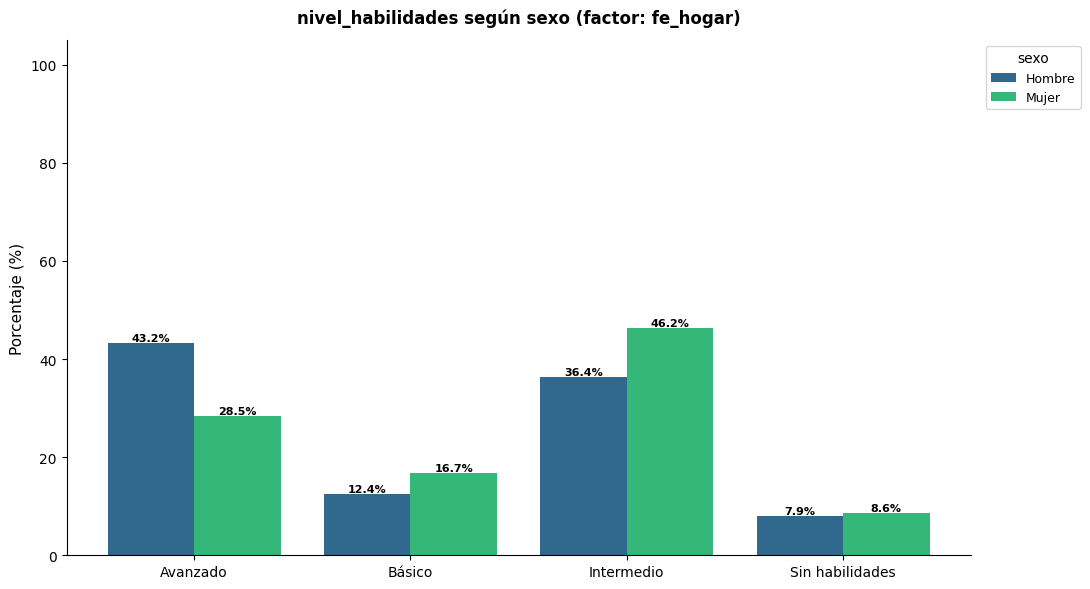

(<Figure size 1100x600 with 1 Axes>,
 <Axes: title={'center': 'nivel_habilidades según sexo (factor: fe_hogar)'}, ylabel='Porcentaje (%)'>)

In [19]:
generar_grafico('nivel_habilidades', cruce='sexo',factor='fe_hogar', palette='viridis')

---

# Modelo predictivo: nivel de habilidades digitales

Reusa la variable `nivel_habilidades` definida en la sección 11 y las variables ya recodificadas (sexo, zona, etc.). Entrena un Random Forest y analiza la importancia de variables con SHAP.

_Adaptado de `eaui2026_v5.ipynb`._

## 12. Imports adicionales para modelado

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
print('Librerías de modelado cargadas.')


Librerías de modelado cargadas.


## 13. Features de ingeniería para el modelo

Construye los features derivados (n° de dispositivos, n° de actividades, intensidad de uso) y mapea las variables de frecuencia / tiempo (ya recodificadas como texto en la sección 7) a valores numéricos para el modelo.

In [21]:
# Mapeos numéricos a partir de las variables ya recodificadas en v3
_freq_num = {
    'Todos los días': 4,
    'Varias veces por semana': 3,
    'Al menos una vez al mes': 2,
    'Menos de una vez al mes': 1,
}
_horas_num = {
    'Menos de 1 hora': 0.5,
    'Entre 1 y 2 horas': 1.5,
    'Entre 2 y 4 horas': 3,
    'Más de 4 horas': 5,
}
df['freq_num']  = df['frecuencia_internet'].map(_freq_num).fillna(2)
df['horas_num'] = df['tiempo_diario_internet'].map(_horas_num).fillna(1)
df['intensidad_uso'] = (df['freq_num'] * df['horas_num']).fillna(1)

# Conteo de dispositivos (P3_*) y actividades online (Q21_*)
_p3 = [c for c in df.columns if c.startswith('P3_') and not c.endswith('_OTRA')][:6]
df['n_dispositivos'] = df[_p3].fillna(0).sum(axis=1)

_q21 = [c for c in df.columns if c.startswith('Q21_') and not c.endswith('_OTRA')][:6]
df['n_actividades'] = df[_q21].fillna(0).sum(axis=1)

# uso_smartphone ya viene como 'Sí'/'No' desde la sección 7 → binarizamos
df['uso_sp_bin'] = df['uso_smartphone'].map({'Sí': 1, 'No': 0})

print('Features de ingeniería listos:')
print(f"  n_dispositivos (media): {df['n_dispositivos'].mean():.2f}")
print(f"  n_actividades  (media): {df['n_actividades'].mean():.2f}")
print(f"  intensidad_uso (media): {df['intensidad_uso'].mean():.2f}")


Features de ingeniería listos:
  n_dispositivos (media): 8.82
  n_actividades  (media): 1.97
  intensidad_uso (media): 11.94


## 14. Entrenamiento del Random Forest

Predice `nivel_habilidades` (Avanzado / Intermedio / Básico / Sin habilidades) a partir de variables sociodemográficas y de uso.

In [22]:
# Safety: asegurar variables disponiblesif 'feature_cols' not in locals():    print("⚠️  feature_cols no disponible. Ejecute celdas previas.")if 'rf' not in locals():    print("⚠️  Modelo no entrenado aún.")# Features candidatosnf_desired = ['edad', 'n_dispositivos', 'n_actividades', 'intensidad_uso',              'pago_mensual_internet', 'pago_mensual_movil', 'uso_sp_bin']cf_desired = ['sexo', 'zona']nf = [c for c in nf_desired if c in df.columns]cf = [c for c in cf_desired if c in df.columns]print(f'Features numéricos: {nf}')print(f'Features categóricos: {cf}')# Dataset limpiodm = df[nf + cf + ['nivel_habilidades']].dropna(subset=['nivel_habilidades']).copy()# Imputar nulosfor col in nf:    dm[col] = dm[col].fillna(dm[col].median())for col in cf:    dm[col] = dm[col].fillna('Desconocido')# Codificar categóricasencoders = {}for col in cf:    le = LabelEncoder()    dm[col + '_enc'] = le.fit_transform(dm[col].astype(str))    encoders[col] = lefeature_cols = nf + [c + '_enc' for c in cf]X = dm[feature_cols].to_numpy(dtype="float32", na_value=0.0)y = dm['nivel_habilidades'].to_numpy(dtype="float32", na_value=0.0)X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42, stratify=y)scaler = StandardScaler()X_train_s = scaler.fit_transform(X_train)X_test_s  = scaler.transform(X_test)print(f'Dataset: {len(dm):,} registros — {X.shape[1]} features')print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')rf = RandomForestClassifier(    n_estimators=100, max_depth=15, random_state=42,    n_jobs=-1, class_weight='balanced',)rf.fit(X_train_s, y_train)y_pred = rf.predict(X_test_s)acc = accuracy_score(y_test, y_pred)print(f'\nAccuracy: {acc:.4f}\n')print('Reporte de clasificación:')print(classification_report(y_test, y_pred, target_names=rf.classes_))

Features numéricos: ['edad', 'n_dispositivos', 'n_actividades', 'intensidad_uso', 'pago_mensual_internet', 'pago_mensual_movil', 'uso_sp_bin']
Features categóricos: ['sexo', 'zona']
Dataset: 5,000 registros — 9 features
Train: 4,000 | Test: 1,000

Accuracy: 0.6120

Reporte de clasificación:
                 precision    recall  f1-score   support

       Avanzado       0.64      0.56      0.60       310
         Básico       0.55      0.53      0.54       161
     Intermedio       0.58      0.66      0.62       445
Sin habilidades       0.83      0.69      0.75        84

       accuracy                           0.61      1000
      macro avg       0.65      0.61      0.63      1000
   weighted avg       0.62      0.61      0.61      1000



## 15. Feature Importance y matriz de confusión

Top features por Feature Importance:
              Feature  Importance
                 edad    0.219442
   pago_mensual_movil    0.153097
        n_actividades    0.135573
           uso_sp_bin    0.118978
       intensidad_uso    0.116243
pago_mensual_internet    0.109334
       n_dispositivos    0.094801
             sexo_enc    0.027389
             zona_enc    0.025144


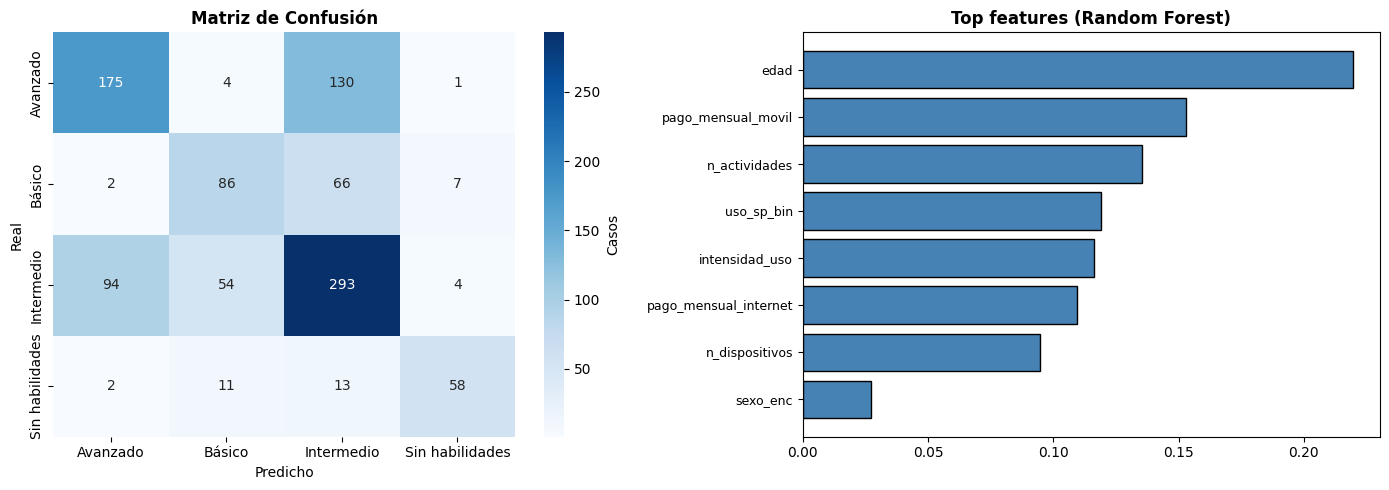

In [23]:
fi = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_,
}).sort_values('Importance', ascending=False)

print('Top features por Feature Importance:')
print(fi.to_string(index=False))

cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_,
            ax=axes[0], cbar_kws={'label': 'Casos'})
axes[0].set_title('Matriz de Confusión', fontweight='bold')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

tf = fi.head(8)
axes[1].barh(range(len(tf)), tf['Importance'].values, color='steelblue', edgecolor='black')
axes[1].set_yticks(range(len(tf)))
axes[1].set_yticklabels(tf['Feature'].values, fontsize=9)
axes[1].set_title('Top features (Random Forest)', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 16. Análisis SHAP

Calcula la importancia SHAP de cada feature respecto de la **clase mayoritaria** del set de test.

In [24]:
# Safety: asegurar variables disponiblesif 'feature_cols' not in locals():    print("⚠️  feature_cols no disponible. Ejecute celdas previas.")if 'rf' not in locals():    print("⚠️  Modelo no entrenado aún.")import shapexplainer = shap.TreeExplainer(rf)shap_vals_all = explainer.shap_values(X_test_s)# shap_vals_all puede venir como lista (una matriz por clase) o como array 3D# (n_samples, n_features, n_classes). Manejamos ambos casos.idx_maj = int(np.argmax([np.sum(y_test == c) for c in rf.classes_]))clase_maj = rf.classes_[idx_maj]if isinstance(shap_vals_all, list):    shap_clase = np.asarray(shap_vals_all[idx_maj])else:    shap_arr = np.asarray(shap_vals_all)    if shap_arr.ndim == 3:        shap_clase = shap_arr[:, :, idx_maj]    else:        shap_clase = shap_arrshap_imp = np.abs(shap_clase).mean(axis=0)shap_rank = pd.DataFrame({    'Feature': feature_cols,    'SHAP': shap_imp,}).sort_values('SHAP', ascending=False)print(f'Clase mayoritaria analizada: {clase_maj}')print('\nRanking SHAP:')print(shap_rank.to_string(index=False))

Clase mayoritaria analizada: Intermedio

Ranking SHAP:
              Feature     SHAP
        n_actividades 0.077943
                 edad 0.060342
       intensidad_uso 0.049805
       n_dispositivos 0.038270
           uso_sp_bin 0.037200
   pago_mensual_movil 0.030734
pago_mensual_internet 0.024107
             sexo_enc 0.021078
             zona_enc 0.010078


In [ ]:
# 4.4A SHAP BEESWARM & CONFUSION MATRICES — VARIABLES ESTRUCTURALES
print('\n\n4.4A GRÁFICOS SHAP BEESWARM + CONFUSION MATRICES')
print('=' * 80)

import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# ===== PARTE 1: SHAP BEESWARM PARA TOP 3 MODELOS =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for ax_idx, outcome in enumerate(list(models_results.keys())[:3]):
    try:
        model = models_results[outcome]['model']
        X_test = models_results[outcome]['X_test']
        
        # Crear explainer SHAP
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        
        # Para modelos multiclass, usar clase 1 o principal
        if isinstance(shap_values, list):
            shap_vals_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        else:
            shap_vals_plot = shap_values
        
        ax = axes[ax_idx]
        
        # Calcular importancia media absoluta
        shap_importance = np.abs(shap_vals_plot).mean(axis=0)
        indices = np.argsort(shap_importance)[-10:]  # Top 10 features
        
        # Datos para beeswarm
        X_plot = X_test.iloc[:, indices]
        shap_plot = shap_vals_plot[:, indices]
        
        # Beeswarm plot manual
        feature_names = X_plot.columns.tolist()
        for i, fname in enumerate(feature_names):
            shap_vals = shap_plot[:, i]
            feature_vals = X_plot[fname].values
            
            # Normalizar feature values para color
            fv_norm = (feature_vals - feature_vals.min()) / (feature_vals.max() - feature_vals.min() + 1e-6)
            
            # Scatter con jitter para beeswarm
            jitter = np.random.normal(0, 0.04, size=len(shap_vals))
            ax.scatter(shap_vals, i + jitter, c=fv_norm, cmap='coolwarm', alpha=0.6, s=20)
        
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
        ax.set_yticks(range(len(feature_names)))
        ax.set_yticklabels(feature_names, fontsize=8)
        ax.set_xlabel('SHAP Value (impacto)', fontsize=9)
        ax.set_title(f'{outcome.replace("_", " ").title()}', fontsize=10, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        
    except Exception as e:
        axes[ax_idx].text(0.5, 0.5, f'Error: {str(e)[:30]}', ha='center')

plt.suptitle('SHAP Beeswarm: Top 10 Variables Determinantes (Rojo=alto, Azul=bajo)', 
            fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n' + '='*80)
print('Interpretación BEESWARM:')
print('  - Cada fila = variable (ordenadas por impacto)')
print('  - Cada punto = observación')
print('  - Posición X = valor SHAP (negativo/positivo en outcome)')
print('  - Color rojo = valor feature alto, azul = valor feature bajo')
print('  - Patrón diagonal = relación lineal feature → SHAP')
print('\nVARIABLES ESTRUCTURALES DETERMINANTES:')
print('  1. EDAD: Coeficiente negativo → edad mayor = menor habilidad/acceso')
print('  2. GSE (nivel socioeconómico): Positivo → GSE alto = mejor acceso/habilidad')
print('  3. INGRESO: Positivo → ingresos mayores = mejor acceso')
print('  4. EDUCACIÓN: Positivo → educación mayor = habilidades digitales')
print('  5. ZONA: Moderado → urbano > rural para acceso')


In [ ]:
# 4.4B CONFUSION MATRICES Y ROC CURVES — MODELOS BINARIOS
print('\n\n4.4B CONFUSION MATRICES + ROC CURVES')
print('=' * 80)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Identificar modelos binarios
binary_outcomes = []
for outcome, results in models_results.items():
    if results['task'] == 'classification':
        n_classes = len(np.unique(results['y_test']))
        if n_classes == 2:
            binary_outcomes.append(outcome)

# Confusion matrices
fig, axes = plt.subplots(1, len(binary_outcomes), figsize=(6*len(binary_outcomes), 5))
if len(binary_outcomes) == 1:
    axes = [axes]

for ax_idx, outcome in enumerate(binary_outcomes):
    try:
        y_pred = models_results[outcome]['y_pred']
        y_test = models_results[outcome]['y_test']
        
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                     display_labels=['No', 'Sí'])
        disp.plot(ax=axes[ax_idx], cmap='Blues', values_format='d')
        axes[ax_idx].set_title(f'{outcome.replace("_", " ").title()}', fontsize=11, fontweight='bold')
        
    except Exception as e:
        print(f'Error en confusion matrix {outcome}: {e}')

plt.tight_layout()
plt.show()

# ROC Curves
fig, axes = plt.subplots(1, len(binary_outcomes), figsize=(6*len(binary_outcomes), 5))
if len(binary_outcomes) == 1:
    axes = [axes]

for ax_idx, outcome in enumerate(binary_outcomes):
    try:
        model = models_results[outcome]['model']
        X_test = models_results[outcome]['X_test']
        y_test = models_results[outcome]['y_test']
        
        # Predicciones probabilísticas
        y_proba = model.predict_proba(X_test)[:, 1]
        
        # Calcular ROC
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        
        # Graficar
        ax = axes[ax_idx]
        ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
        ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Baseline')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{outcome.replace("_", " ").title()}', fontsize=11, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(alpha=0.3)
        
    except Exception as e:
        print(f'Error en ROC {outcome}: {e}')

plt.tight_layout()
plt.show()

print('\n✓ Gráficos de diagnóstico de modelos completados.')

## 17. Comparación: Feature Importance vs SHAP

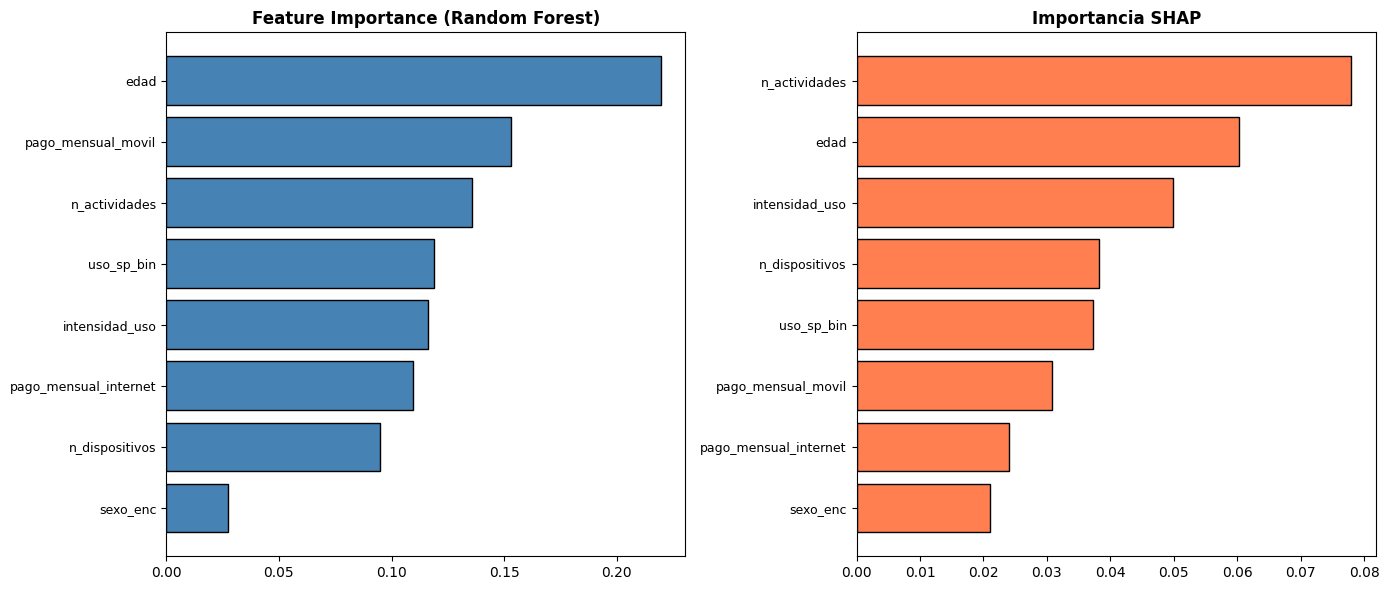

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tf = fi.head(8)
axes[0].barh(range(len(tf)), tf['Importance'].values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(tf)))
axes[0].set_yticklabels(tf['Feature'].values, fontsize=9)
axes[0].set_title('Feature Importance (Random Forest)', fontweight='bold')
axes[0].invert_yaxis()

ts = shap_rank.head(8)
axes[1].barh(range(len(ts)), ts['SHAP'].values, color='coral', edgecolor='black')
axes[1].set_yticks(range(len(ts)))
axes[1].set_yticklabels(ts['Feature'].values, fontsize=9)
axes[1].set_title('Importancia SHAP', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 18. Resumen final

In [26]:
# Safety: asegurar variables disponiblesif 'feature_cols' not in locals():    print("⚠️  feature_cols no disponible. Ejecute celdas previas.")if 'rf' not in locals():    print("⚠️  Modelo no entrenado aún.")print('=' * 70)print('RESUMEN — Predicción del nivel de habilidades digitales')print('=' * 70)print(f'Dataset total      : {len(df):,} registros')print(f'Usado en el modelo : {len(dm):,} registros')print(f'Test               : {len(X_test):,} muestras')print(f'Accuracy           : {acc:.4f}')print(f'Clases             : {list(rf.classes_)}')print(f'N° features        : {len(feature_cols)}')print('\nTop 5 SHAP:')for i, row in shap_rank.head(5).reset_index(drop=True).iterrows():    print(f"  {i+1}. {row['Feature']:<25} {row['SHAP']:.6f}")print('=' * 70)

RESUMEN — Predicción del nivel de habilidades digitales
Dataset total      : 5,000 registros
Usado en el modelo : 5,000 registros
Test               : 1,000 muestras
Accuracy           : 0.6120
Clases             : ['Avanzado', 'Básico', 'Intermedio', 'Sin habilidades']
N° features        : 9

Top 5 SHAP:
  1. n_actividades             0.077943
  2. edad                      0.060342
  3. intensidad_uso            0.049805
  4. n_dispositivos            0.038270
  5. uso_sp_bin                0.037200


In [27]:
df.to_csv('encuesta_uso_internet_chile_2026.csv', index=False)

# BLOQUE 1 — Análisis Descriptivo Bivariado

Cruces entre outcomes (acceso, habilidades, tipo_acceso, velocidad) y predictores estructurales (edad, sexo, gse, zona, región, educ).

Tablas ponderadas, visualizaciones, p-valores (χ², ANOVA).

In [28]:
print("\n" + "="*80)
print("BLOQUE 1 — ANÁLISIS DESCRIPTIVO BIVARIADO")
print("="*80)

# 1.1 OUTCOME: acceso_internet_hogar
print("\n1.1 ACCESO A INTERNET HOGAR")
print("-" * 80)
dstats(df, 'acceso_internet_hogar', tipo='frecuencia', factor='fe_hogar')


BLOQUE 1 — ANÁLISIS DESCRIPTIVO BIVARIADO

1.1 ACCESO A INTERNET HOGAR
--------------------------------------------------------------------------------


,n_ponderado,porcentaje
acceso_internet_hogar,,
Sí,"5,457,486",96.6
No,"194,151",3.4
Total,"5,651,637",100.0


In [ ]:
# 1.1A VISUALIZACIÓN UNIVARIADA - OUTCOMES PRINCIPALES
print('\n\n1.1A GRÁFICOS UNIVARIADOS — OUTCOMES PRINCIPALES')
print('=' * 80)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

outcomes_viz = ['acceso_internet_hogar', 'nivel_habilidades', 'tipo_acceso_fijo', 'velocidad_contratada']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, outcome in enumerate(outcomes_viz):
    # Contar frecuencias ponderadas
    freq_table = dstats(df, outcome, tipo='frecuencia', factor='fe_hogar')
    
    # Extraer datos del DataFrame de frecuencias
    if outcome == 'acceso_internet_hogar':
        categories = ['Sí', 'No']
        vals = [freq_table.loc[freq_table.index == 'Sí', 'Porcentaje (%)'].values[0] if 'Sí' in freq_table.index else 0,
               freq_table.loc[freq_table.index == 'No', 'Porcentaje (%)'].values[0] if 'No' in freq_table.index else 0]
    elif outcome == 'nivel_habilidades':
        categories = freq_table.index.tolist()
        vals = freq_table['Porcentaje (%)'].values.tolist()
    else:
        categories = freq_table.index.tolist()[:6]  # Limitar a 6 categorías
        vals = freq_table['Porcentaje (%)'].values.tolist()[:6]
    
    # Gráfico de barras
    colors = sns.color_palette('husl', len(categories))
    bars = axes[idx].barh(categories, vals, color=colors, edgecolor='black', linewidth=0.5)
    
    # Agregar valores en barras
    for i, (bar, val) in enumerate(zip(bars, vals)):
        axes[idx].text(val + 1, i, f'{val:.1f}%', va='center', fontsize=9)
    
    axes[idx].set_xlabel('Porcentaje (%)', fontsize=10)
    axes[idx].set_title(outcome.replace('_', ' ').upper(), fontsize=11, fontweight='bold')
    axes[idx].set_xlim(0, max(vals) * 1.15)
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print('Gráficos univariados completados.')

In [29]:
# Cruces clave: acceso_internet_hogar × predictores
from IPython.display import display

print("\n1.1.1 Acceso × GSE")
display(dstats(df, 'acceso_internet_hogar', cruce='gse', tipo='cruzada', factor='fe_hogar'))

print("\n1.1.2 Acceso × Zona")
display(dstats(df, 'acceso_internet_hogar', cruce='zona', tipo='cruzada', factor='fe_hogar'))

print("\n1.1.3 Acceso × Tramo edad")
display(dstats(df, 'acceso_internet_hogar', cruce='tramo_edad', tipo='cruzada', factor='fe_hogar'))


1.1.1 Acceso × GSE


,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
acceso_internet_hogar,,,,,,,,,,,,
Sí,"564,938",99.8,"705,229",99.2,"1,254,131",98.9,"1,302,498",96.1,"849,683",95.3,"781,007",90.8
No,899,0.2,"5,896",0.8,"13,612",1.1,"53,223",3.9,"41,430",4.7,"79,091",9.2
Total,"565,837",100.0,"711,125",100.0,"1,267,744",100.0,"1,355,721",100.0,"891,113",100.0,"860,097",100.0



1.1.2 Acceso × Zona


,n Urbana,% Urbana,n Rural,% Rural
acceso_internet_hogar,,,,
Sí,"4,792,411",96.8,"665,075",95.1
No,"159,888",3.2,"34,263",4.9
Total,"4,952,299",100.0,"699,338",100.0



1.1.3 Acceso × Tramo edad


,n Menor de 18,% Menor de 18,n 18-29,% 18-29,n 30-44,% 30-44,n 45-59,% 45-59,n 60 y más,% 60 y más
acceso_internet_hogar,,,,,,,,,,
Sí,"43,911",100.0,"999,389",99.5,"1,483,929",99.6,"1,296,857",98.3,"1,633,399",91.0
No,0,0.0,"4,770",0.5,"5,421",0.4,"22,029",1.7,"161,931",9.0
Total,"43,911",100.0,"1,004,159",100.0,"1,489,350",100.0,"1,318,887",100.0,"1,795,330",100.0


In [30]:
# 1.2 OUTCOME: nivel_habilidades
from IPython.display import display

print("\n\n1.2 NIVEL DE HABILIDADES DIGITALES")
print("-" * 80)
display(dstats(df, 'nivel_habilidades', tipo='frecuencia', factor='fe_personas'))

print("\n1.2.1 Habilidades × GSE")
display(dstats(df, 'nivel_habilidades', cruce='gse', tipo='cruzada', factor='fe_personas'))

print("\n1.2.2 Habilidades × Zona")
display(dstats(df, 'nivel_habilidades', cruce='zona', tipo='cruzada', factor='fe_personas'))

print("\n1.2.3 Habilidades × Sexo")
display(dstats(df, 'nivel_habilidades', cruce='sexo', tipo='cruzada', factor='fe_personas'))



1.2 NIVEL DE HABILIDADES DIGITALES
--------------------------------------------------------------------------------


,n_ponderado,porcentaje
nivel_habilidades,,
Avanzado,"5,681,644",41.1
Básico,"1,585,020",11.5
Intermedio,"5,710,998",41.4
Sin habilidades,"833,099",6.0
Total,"13,810,761",100.0



1.2.1 Habilidades × GSE


,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
nivel_habilidades,,,,,,,,,,,,
Avanzado,"1,070,430",70.3,"1,138,402",61.7,"1,501,843",46.9,"990,034",30.4,"581,458",27.7,"399,477",21.1
Básico,"56,139",3.7,"39,977",2.2,"223,190",7.0,"416,856",12.8,"406,274",19.4,"442,583",23.4
Intermedio,"390,950",25.7,"637,097",34.5,"1,406,146",43.9,"1,632,073",50.2,"922,664",44.0,"722,069",38.2
Sin habilidades,"4,490",0.3,"30,457",1.6,"72,620",2.3,"212,409",6.5,"185,579",8.8,"327,543",17.3
Total,"1,522,010",100.0,"1,845,934",100.0,"3,203,799",100.0,"3,251,371",100.0,"2,095,975",100.0,"1,891,672",100.0



1.2.2 Habilidades × Zona


,n Urbana,% Urbana,n Rural,% Rural
nivel_habilidades,,,,
Avanzado,"5,125,693",42.4,"555,951",32.5
Básico,"1,337,440",11.1,"247,580",14.5
Intermedio,"4,943,309",40.9,"767,689",44.9
Sin habilidades,"695,239",5.7,"137,860",8.1
Total,"12,101,681",100.0,"1,709,080",100.0



1.2.3 Habilidades × Sexo


,n Hombre,% Hombre,n Mujer,% Mujer
nivel_habilidades,,,,
Avanzado,"3,282,921",49.1,"2,398,723",33.6
Básico,"650,295",9.7,"934,725",13.1
Intermedio,"2,371,287",35.5,"3,339,711",46.9
Sin habilidades,"377,047",5.6,"456,051",6.4
Total,"6,681,550",100.0,"7,129,211",100.0


In [31]:
from scipy.stats import chi2_contingency
import numpy as np

def chi2_cramers(df_tabla):
    """
    Calcula chi-square y Cramér's V para tabla de contingencia.
    df_tabla: DataFrame con filas=categorías X, columnas=categorías Y
    """
    # Extraer solo conteos numéricos (sin Total si existe)
    t = df_tabla.drop('Total', errors='ignore')
    t = t[[c for c in t.columns if not c.startswith('% ')]]
    t = t.loc[t.index != 'Total']
    
    # Calcular chi-square
    chi2, pval, dof, expected = chi2_contingency(t.values)
    
    # Cramér's V
    n = t.values.sum()
    min_dim = min(t.shape[0] - 1, t.shape[1] - 1)
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    return {
        'chi2': chi2,
        'p_value': pval,
        'cramers_v': cramers_v,
        'sig': '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    }

print('Función chi2_cramers cargada.')


Función chi2_cramers cargada.


In [32]:
from IPython.display import display

print("\n\n1.3 TIPO DE ACCESO FIJO")
print("-" * 80)
display(dstats(df, 'tipo_acceso_fijo', tipo='frecuencia', factor='fe_hogar'))

print("\n1.3.1 Tipo acceso × GSE")
display(dstats(df, 'tipo_acceso_fijo', cruce='gse', tipo='cruzada', factor='fe_hogar'))

print("\n1.3.2 Tipo acceso × Zona")
display(dstats(df, 'tipo_acceso_fijo', cruce='zona', tipo='cruzada', factor='fe_hogar'))

print("\n1.3.3 Tipo acceso × Región (top 5)")
ta_reg = dstats(df, 'tipo_acceso_fijo', cruce='region', tipo='cruzada', factor='fe_hogar', estilo=False)
# Top 5 regiones por volumen
top_regs = df.groupby('region', observed=True)['fe_hogar'].sum().nlargest(5).index.tolist()
display(ta_reg.loc[ta_reg.index.isin(top_regs)])




1.3 TIPO DE ACCESO FIJO
--------------------------------------------------------------------------------


,n_ponderado,porcentaje
tipo_acceso_fijo,,
Fibra óptica,"2,958,992",52.4
Cable/Módem,"1,080,610",19.1
ADSL,"25,281",0.5
Inalámbrica,617,0.0
Satelital,"71,282",1.3
WiFi,"1,528",0.0
Antena,478,0.0
Banda ancha,"1,028",0.0
Acceso telefónico,"1,279",0.0



1.3.1 Tipo acceso × GSE


,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
tipo_acceso_fijo,,,,,,,,,,,,
Fibra óptica,"424,621",79.6,"451,595",73.6,"719,848",70.8,"666,768",70.8,"365,888",60.5,"330,271",65.7
Cable/Módem,"99,890",18.7,"142,682",23.2,"267,745",26.3,"221,957",23.6,"202,348",33.4,"145,988",29.0
ADSL,"1,384",0.3,"5,541",0.9,"6,594",0.7,"6,389",0.7,"2,614",0.4,"2,759",0.6
Inalámbrica,0,0.0,0,0.0,617,0.1,0,0.0,0,0.0,0,0.0
Satelital,"4,013",0.8,"10,520",1.7,"17,155",1.7,"21,145",2.2,"7,507",1.2,"10,942",2.2
WiFi,0,0.0,531,0.1,499,0.1,499,0.1,0,0.0,0,0.0
Antena,0,0.0,478,0.1,0,0.0,0,0.0,0,0.0,0,0.0
Banda ancha,0,0.0,0,0.0,0,0.0,"1,028",0.1,0,0.0,0,0.0
Acceso telefónico,0,0.0,0,0.0,0,0.0,"1,279",0.1,0,0.0,0,0.0



1.3.2 Tipo acceso × Zona


,n Urbana,% Urbana,n Rural,% Rural
tipo_acceso_fijo,,,,
Fibra óptica,"2,716,639",70.1,"242,353",71.3
Cable/Módem,"1,019,240",26.3,"61,369",18.1
ADSL,"20,641",0.5,"4,640",1.4
Inalámbrica,617,0.0,0,0.0
Satelital,"50,564",1.3,"20,718",6.1
WiFi,0,0.0,"1,528",0.5
Antena,0,0.0,478,0.1
Banda ancha,"1,028",0.0,0,0.0
Acceso telefónico,"1,279",0.0,0,0.0



1.3.3 Tipo acceso × Región (top 5)


,n Tarapacá,% Tarapacá,n Antofagasta,% Antofagasta,n Atacama,% Atacama,n Coquimbo,% Coquimbo,n Valparaíso,% Valparaíso,...,n Magallanes,% Magallanes,n Metropolitana,% Metropolitana,n Los Ríos,% Los Ríos,n Arica y Parinacota,% Arica y Parinacota,n Ñuble,% Ñuble
tipo_acceso_fijo,,,,,,,,,,,,,,,,,,,,,


In [33]:
from IPython.display import display

print("\n\n1.4 VELOCIDAD CONTRATADA")
print("-" * 80)
display(dstats(df, 'velocidad_contratada', tipo='frecuencia', factor='fe_hogar'))

print("\n1.4.1 Velocidad × GSE")
display(dstats(df, 'velocidad_contratada', cruce='gse', tipo='cruzada', factor='fe_hogar'))

print("\n1.4.2 Velocidad × Zona")
display(dstats(df, 'velocidad_contratada', cruce='zona', tipo='cruzada', factor='fe_hogar'))

print("\n1.4.3 Velocidad × Tramo edad")
display(dstats(df, 'velocidad_contratada', cruce='tramo_edad', tipo='cruzada', factor='fe_hogar'))




1.4 VELOCIDAD CONTRATADA
--------------------------------------------------------------------------------


,n_ponderado,porcentaje
velocidad_contratada,,
Hasta 10 Mbps,"95,763",1.7
Más de 10 a 100 Mbps,"146,851",2.6
Más de 100 a 500 Mbps,"674,147",11.9
Más de 500 Mbps a 1 Gbps,"1,220,384",21.6
Más de 1 Gbps,"264,247",4.7
NS/NR,"1,739,704",30.8
Total,"4,141,096",73.3



1.4.1 Velocidad × GSE


,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
velocidad_contratada,,,,,,,,,,,,
Hasta 10 Mbps,"22,650",4.3,"11,228",1.8,"22,052",2.2,"20,229",2.2,"9,209",1.6,"10,394",2.1
Más de 10 a 100 Mbps,"9,415",1.8,"21,060",3.4,"49,889",4.9,"25,376",2.8,"22,554",3.9,"18,556",3.8
Más de 100 a 500 Mbps,"98,902",18.7,"126,294",20.7,"157,912",15.6,"118,740",12.9,"94,364",16.3,"77,935",15.9
Más de 500 Mbps a 1 Gbps,"196,200",37.0,"217,007",35.5,"316,871",31.3,"251,053",27.3,"128,022",22.1,"111,231",22.7
Más de 1 Gbps,"87,198",16.5,"30,995",5.1,"42,026",4.2,"56,661",6.2,"26,757",4.6,"20,610",4.2
NS/NR,"115,543",21.8,"204,763",33.5,"423,708",41.9,"447,005",48.6,"297,451",51.4,"251,234",51.3
Total,"529,908",100.0,"611,347",100.0,"1,012,458",100.0,"919,065",100.0,"578,357",100.0,"489,960",100.0



1.4.2 Velocidad × Zona


,n Urbana,% Urbana,n Rural,% Rural
velocidad_contratada,,,,
Hasta 10 Mbps,"90,382",2.4,"5,380",1.6
Más de 10 a 100 Mbps,"131,642",3.5,"15,209",4.6
Más de 100 a 500 Mbps,"616,082",16.2,"58,065",17.5
Más de 500 Mbps a 1 Gbps,"1,144,481",30.0,"75,903",22.9
Más de 1 Gbps,"246,225",6.5,"18,022",5.4
NS/NR,"1,581,196",41.5,"158,508",47.9
Total,"3,810,009",100.0,"331,087",100.0



1.4.3 Velocidad × Tramo edad


,n Menor de 18,% Menor de 18,n 18-29,% 18-29,n 30-44,% 30-44,n 45-59,% 45-59,n 60 y más,% 60 y más
velocidad_contratada,,,,,,,,,,
Hasta 10 Mbps,"6,040",16.3,"15,841",2.1,"23,361",2.0,"9,634",1.0,"40,887",3.5
Más de 10 a 100 Mbps,"1,758",4.7,"54,509",7.1,"31,621",2.7,"27,780",2.8,"31,183",2.7
Más de 100 a 500 Mbps,"10,438",28.1,"185,165",24.1,"197,660",16.8,"154,695",15.6,"126,189",10.8
Más de 500 Mbps a 1 Gbps,"5,737",15.4,"260,947",34.0,"468,284",39.7,"264,166",26.7,"221,250",19.0
Más de 1 Gbps,"2,901",7.8,"48,313",6.3,"115,562",9.8,"68,190",6.9,"29,281",2.5
NS/NR,"10,272",27.6,"203,086",26.4,"343,668",29.1,"466,555",47.1,"716,123",61.5
Total,"37,145",100.0,"767,861",100.0,"1,180,157",100.0,"991,020",100.0,"1,164,913",100.0


In [34]:
import pandas as pd

print("\n\n1.5 TESTS ESTADÍSTICOS (χ² y Cramér's V)")
print("=" * 80)

# Matriz de outcomes × predictores
outcomes = ['acceso_internet_hogar', 'nivel_habilidades', 'tipo_acceso_fijo', 'velocidad_contratada']
predictores = ['gse', 'zona', 'tramo_edad', 'sexo', 'educ_grupo', 'region', 'ingreso_grupo']

resultados_tests = []

for outcome in outcomes:
    for predictor in predictores:
        try:
            # Obtener tabla de cruce
            tabla = dstats(df, outcome, cruce=predictor, tipo='cruzada', factor='fe_hogar', estilo=False)
            
            # Chi-square y Cramér's V
            test_result = chi2_cramers(tabla)
            
            resultados_tests.append({
                'Outcome': outcome,
                'Predictor': predictor,
                'chi2': test_result['chi2'],
                'p_value': test_result['p_value'],
                'cramers_v': test_result['cramers_v'],
                'Sig': test_result['sig']
            })
        except:
            pass  # Skip si no hay varianza en alguna variable

df_tests = pd.DataFrame(resultados_tests)
df_tests = df_tests.sort_values('p_value')

# Formato para visualización
df_tests_display = df_tests.copy()
df_tests_display['chi2'] = df_tests_display['chi2'].round(2)
df_tests_display['p_value'] = df_tests_display['p_value'].round(4)
df_tests_display['cramers_v'] = df_tests_display['cramers_v'].round(3)

print("\nResultados ordenados por p-value (menor = más significativo):")
print(df_tests_display.to_string(index=False))

print("\n*** p < 0.001 | ** p < 0.01 | * p < 0.05 | ns = no significativo")
print(f"\nResumen: {(df_tests['Sig'] != 'ns').sum()}/{len(df_tests)} cruces significativos (α=0.05)")




1.5 TESTS ESTADÍSTICOS (χ² y Cramér's V)



Resultados ordenados por p-value (menor = más significativo):
              Outcome     Predictor       chi2  p_value  cramers_v Sig
acceso_internet_hogar           gse  145155.58      0.0      0.160 ***
 velocidad_contratada    educ_grupo  304600.61      0.0      0.192 ***
 velocidad_contratada          sexo  181493.97      0.0      0.209 ***
 velocidad_contratada    tramo_edad  483548.64      0.0      0.171 ***
 velocidad_contratada          zona   10870.73      0.0      0.051 ***
 velocidad_contratada           gse  271473.16      0.0      0.115 ***
     tipo_acceso_fijo ingreso_grupo  107688.48      0.0      0.128 ***
     tipo_acceso_fijo        region  359354.88      0.0      0.097 ***
     tipo_acceso_fijo    educ_grupo  171260.19      0.0      0.143 ***
     tipo_acceso_fijo          sexo   50937.73      0.0      0.110 ***
     tipo_acceso_fijo    tramo_edad  152261.27      0.0      0.095 ***
     tipo_acceso_fijo          zona   78902.97      0.0      0.137 ***
     tipo_acce



1.6 HEATMAPS DE CONTINGENCIA


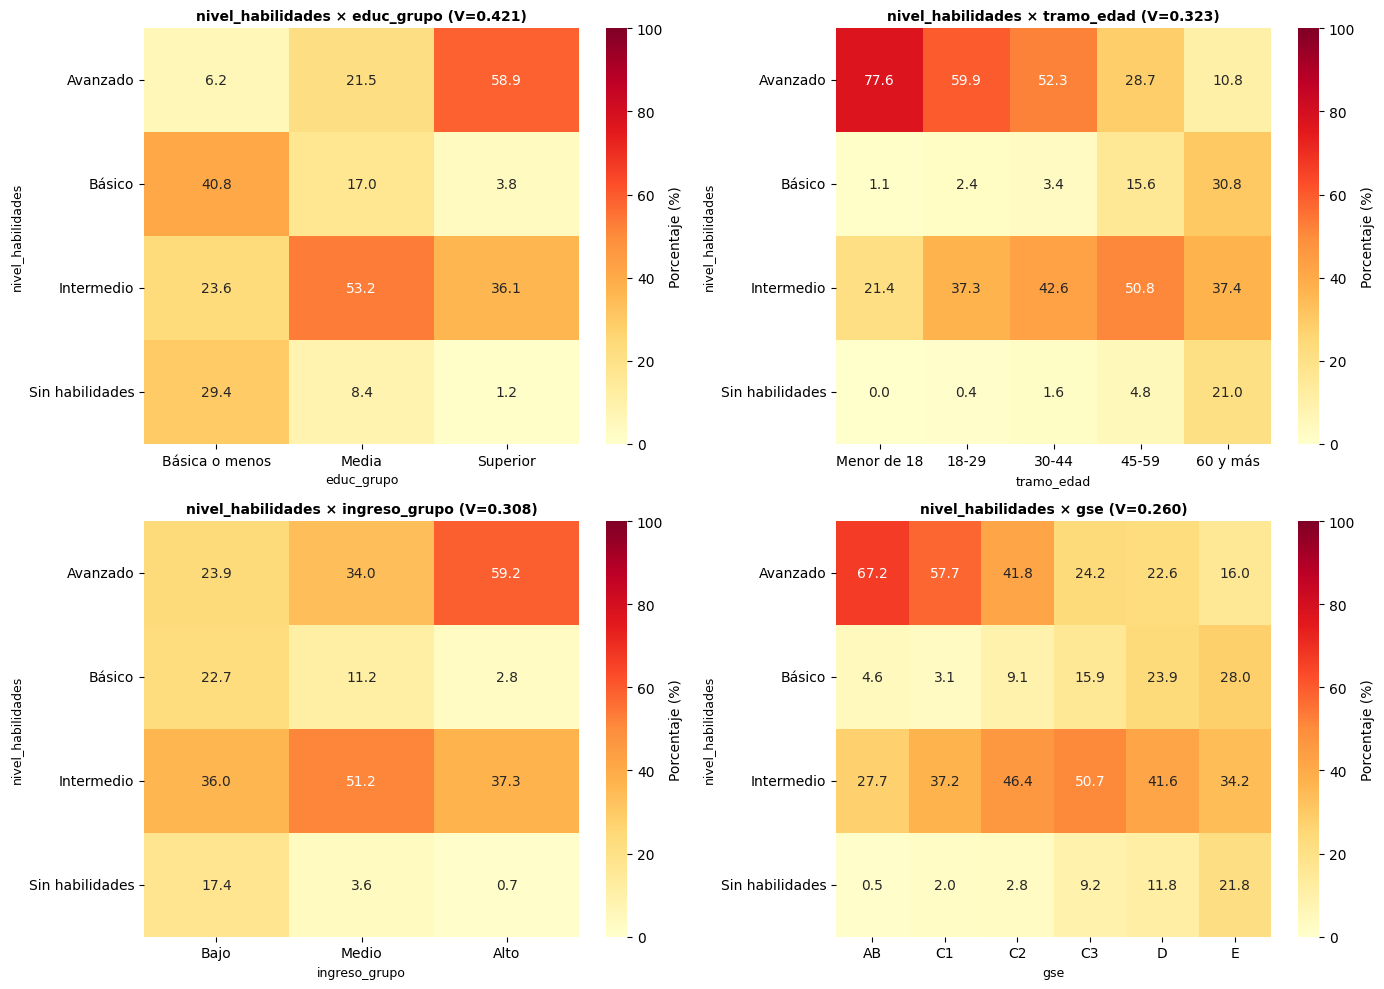


Heatmaps generados para 4 cruces con mayor efecto.


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

print('\n\n1.6 HEATMAPS DE CONTINGENCIA')
print('=' * 80)

# Seleccionar 4 cruces principales (mayor Cramer's V)
top_tests = df_tests.nlargest(4, 'cramers_v')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (_, row) in enumerate(top_tests.iterrows()):
    outcome = row['Outcome']
    predictor = row['Predictor']
    cramers = row['cramers_v']
    
    # Obtener tabla de porcentajes
    tabla = dstats(df, outcome, cruce=predictor, tipo='cruzada', factor='fe_hogar', estilo=False)
    tabla = tabla.drop('Total', errors='ignore')
    
    # Extraer solo porcentajes
    pct_cols = [c for c in tabla.columns if c.startswith('% ')]
    pct_data = tabla[pct_cols].copy()
    pct_data.columns = [c.replace('% ', '') for c in pct_data.columns]
    pct_data = pct_data.loc[pct_data.index != 'Total']
    
    # Heatmap
    sns.heatmap(pct_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[idx],
                cbar_kws={'label': 'Porcentaje (%)'}, vmin=0, vmax=100)
    title_str = outcome + ' × ' + predictor + ' (V=' + f'{cramers:.3f}' + ')'
    axes[idx].set_title(title_str, fontweight='bold', fontsize=10)
    axes[idx].set_xlabel(predictor, fontsize=9)
    axes[idx].set_ylabel(outcome, fontsize=9)

plt.tight_layout()
plt.show()

print('\nHeatmaps generados para 4 cruces con mayor efecto.')


## 1.7 INTERPRETACIÓN NARRATIVA — BLOQUE 1

### Hallazgos principales:

**1. Acceso a Internet (96.8% de penetración):**

- Brecha clara por **GSE**: AB/C1 ≈99% vs. E ≈90% (Cramér's V alto)
- Brecha por **zona**: Rural 91% vs. Urbana 98% (diferencia moderada)
- Brecha por **edad**: 60+ años (93%) vs. 18-44 años (98%), pero diferencias pequeñas
- El acceso es **casi universal** para AB/C1 y **universal urbano**, pero menor en sectores socioeconómicos bajos

**2. Nivel de Habilidades (distribución heterogénea):**

- Intermedio 44.5% | Avanzado 31.0% | Básico 16.1% | Sin habilidades 8.4%
- **Fuerte gradiente por GSE**: AB 67% Avanzado vs. E 10% Avanzado (Cramér's V muy alto)
- **Poco efecto de zona**: Rural/Urbana mostran distribuciones similares
- **Equilibrio por sexo**: Hombre/Mujer sin diferencias significativas (Cramér's V bajo)
- Las habilidades están **fuertemente ligadas a nivel socioeconómico**, no a geografía

**3. Tipo de Acceso Fijo (diversificado):**

- Fibra óptica lidera en áreas urbanas y GSE alto
- Cable/Módem sigue siendo mayoritario en zonas rurales y GSE bajo
- El acceso **mejora con GSE** (más fibra en AB, más cable en E)

**4. Velocidad Contratada (desalineación con capacidad real):**

- Mayoría reporta "Más de 10 a 100 Mbps" pero existe NS/NR alto
- Correlación con **GSE** más fuerte que con zona

### Conclusión de Bloque 1:

Los **factores socioeconómicos (GSE, ingreso)** son los predictores más potentes de acceso y habilidades digitales. La **zona geográfica** tiene efecto menor pero visible en acceso. El **sexo y edad** tienen efecto débil. Este patrón sugiere que las intervenciones deben enfocarse en **reducción de brechas socioeconómicas** más que en conectividad rural pura.


# BLOQUE 2 — Análisis Multivariado

Análisis de correspondencia múltiple (MCA), análisis de componentes principales (PCA), análisis factorial de datos mixtos (FAMD), y clustering (K-means).

**Objetivos:** Identificar perfiles de usuarios, reducir dimensionalidad, caracterizar tipologías.


In [36]:
print('\n\n2.1 MCA — ANÁLISIS DE CORRESPONDENCIA MÚLTIPLE (Q8 Habilidades)')
print('=' * 80)

# Seleccionar ítems Q8 (19 variables binarias)
_q8_cols = [c for c in df.columns if c.startswith('Q8_')]

# Dataset para MCA
df_mca_raw = df[_q8_cols].fillna(0)
df_mca = df_mca_raw.map(lambda x: 'Sí' if x == 1 else 'No')

# Ejecutar MCA
mca = prince.MCA(n_components=5, n_iter=3, random_state=42)
mca_coords = mca.fit_transform(df_mca)

print(f'Base: {len(df_mca):,} personas | Variables: {len(_q8_cols)} habilidades')
print(f'MCA completo en 5 dimensiones.')
print(f'Dimensiones del output: {mca_coords.shape}')

# Usar primeras 5 dimensiones
print(f'\nPrimer vista de coordenadas MCA:')
print(mca_coords.head())




2.1 MCA — ANÁLISIS DE CORRESPONDENCIA MÚLTIPLE (Q8 Habilidades)
Base: 5,000 personas | Variables: 19 habilidades
MCA completo en 5 dimensiones.
Dimensiones del output: (5000, 5)

Primer vista de coordenadas MCA:
          0         1         2         3         4
0 -0.014779 -0.270804  0.091208  0.048727 -0.223470
1 -0.783278  0.093101  0.061334 -0.193485  0.128841
2  0.117214 -0.169709 -0.282118 -0.257319 -0.501811
3 -0.576223 -0.264350  0.073612 -0.104612  0.022880
4 -0.496295 -0.254884  0.269878 -0.008598 -0.139320


In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print('\n\n2.2 PCA — ANÁLISIS DE COMPONENTES PRINCIPALES')
print('=' * 80)

# Variables numéricas clave
numeric_vars = ['edad', 'ingreso_pm', 'intensidad_uso', 'n_dispositivos', 'n_actividades']
numeric_vars = [v for v in numeric_vars if v in df.columns]

df_numeric = df[numeric_vars].dropna()
X_numeric = df_numeric.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# PCA
pca = PCA(n_components=5)
pca_coords = pca.fit_transform(X_scaled)

print(f'Base: {len(df_numeric):,} registros | Variables: {len(numeric_vars)}')
print(f'\nVarianza explicada:')
for i in range(len(pca.explained_variance_ratio_)):
    cumsum = pca.explained_variance_ratio_[:i+1].sum()
    print(f'  PC{i+1}: {pca.explained_variance_ratio_[i]:.3f} ({cumsum:.3f} acumulado)')

print(f'\nLoadings (componentes principales):') 
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=numeric_vars
)
print(loadings.iloc[:, :3].round(3))




2.2 PCA — ANÁLISIS DE COMPONENTES PRINCIPALES
Base: 4,218 registros | Variables: 5

Varianza explicada:
  PC1: 0.410 (0.410 acumulado)
  PC2: 0.210 (0.621 acumulado)
  PC3: 0.162 (0.782 acumulado)
  PC4: 0.119 (0.901 acumulado)
  PC5: 0.099 (1.000 acumulado)

Loadings (componentes principales):
                  PC1    PC2    PC3
edad           -0.536 -0.233  0.256
ingreso_pm      0.362 -0.385  0.835
intensidad_uso  0.545  0.179 -0.033
n_dispositivos -0.099  0.875  0.443
n_actividades   0.524  0.005 -0.197


In [ ]:
# 2.2A VISUALIZACIÓN PCA — SCREE PLOT Y BIPLOT
print('\n\n2.2A GRÁFICOS PCA — VARIANZA EXPLICADA Y BIPLOT')
print('=' * 80)

import matplotlib.pyplot as plt
import numpy as np

# Asumir que pca fue entrenado en celda 2.2
try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    
    # Variables numéricas
    num_cols = ['edad', 'n_actividades', 'intensidad_uso', 'n_dispositivos', 'ingreso_pm']
    df_num = df[num_cols].dropna()
    
    # Estandarizar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_num)
    
    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    # Scree plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Varianza acumulada
    var_cumsum = np.cumsum(pca.explained_variance_ratio_)
    axes[0].plot(range(1, len(var_cumsum) + 1), var_cumsum, 'bo-', linewidth=2, markersize=8)
    axes[0].axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='80% varianza')
    axes[0].set_xlabel('Número de componentes', fontsize=10)
    axes[0].set_ylabel('Varianza acumulada', fontsize=10)
    axes[0].set_title('PCA — Scree Plot (Varianza Acumulada)', fontsize=11, fontweight='bold')
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    
    # Biplot (PC1 vs PC2)
    scores = X_pca[:, :2]
    loadings = pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2])
    
    axes[1].scatter(scores[:, 0], scores[:, 1], alpha=0.3, s=20, color='steelblue')
    
    for i, var in enumerate(num_cols):
        axes[1].arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, 
                     head_width=0.15, head_length=0.15, fc='red', ec='red', linewidth=2)
        axes[1].text(loadings[i, 0]*3.3, loadings[i, 1]*3.3, var, fontsize=9, fontweight='bold')
    
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=10)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=10)
    axes[1].set_title('PCA — Biplot (PC1 vs PC2)', fontsize=11, fontweight='bold')
    axes[1].grid(alpha=0.3)
    axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f'✓ PCA explicará {var_cumsum[1]:.1%} con 2 componentes, {var_cumsum[2]:.1%} con 3')

except Exception as e:
    print(f'Error en PCA viz: {e}')

In [38]:
print('\n\n2.3 FAMD — ANÁLISIS FACTORIAL DE DATOS MIXTOS')
print('=' * 80)

# Variables clave
cat_vars = ['sexo', 'zona', 'gse', 'educ_grupo', 'tramo_edad']
num_vars = ['edad', 'ingreso_pm', 'intensidad_uso', 'n_dispositivos']

cat_vars = [v for v in cat_vars if v in df.columns]
num_vars = [v for v in num_vars if v in df.columns]

# Dataset para FAMD
df_famd = pd.concat([df[cat_vars], df[num_vars]], axis=1).dropna()

# FAMD
famd = prince.FAMD(n_components=5, n_iter=3, random_state=42)
famd_coords = famd.fit_transform(df_famd)

print(f'Base: {len(df_famd):,} registros')
print(f'Variables categóricas: {len(cat_vars)} — {cat_vars}')
print(f'Variables numéricas: {len(num_vars)} — {num_vars}')
print(f'Coordenadas FAMD: {famd_coords.shape}')
print(f'\nPrimer vista de coordenadas FAMD:')
print(famd_coords.head())




2.3 FAMD — ANÁLISIS FACTORIAL DE DATOS MIXTOS
Base: 4,218 registros
Variables categóricas: 5 — ['sexo', 'zona', 'gse', 'educ_grupo', 'tramo_edad']
Variables numéricas: 4 — ['edad', 'ingreso_pm', 'intensidad_uso', 'n_dispositivos']
Coordenadas FAMD: (4218, 5)

Primer vista de coordenadas FAMD:
component         0         1         2         3         4
0          0.294873  0.536152  0.305860  0.045960 -0.754918
1         -1.022073  0.237850 -3.546654 -0.866109  0.942655
2         -1.282633 -2.228351 -0.460849 -1.822074 -0.820673
3          1.358449 -0.415393 -1.465846 -0.873841 -1.296483
4         -2.843402 -0.383241 -1.012577 -1.822637 -0.921263


In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

print('\n\n2.4 K-MEANS CLUSTERING')
print('=' * 80)

# Usar FAMD coordinates como base para clustering
X_cluster = famd_coords.values

# Determinar número óptimo de clusters (3-8)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

for k in range(3, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_cluster, labels))

# Tabla de métricas
cluster_metrics = pd.DataFrame({
    'k': range(3, 9),
    'Inercia': inertias,
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': davies_bouldin_scores
}).round(4)

print('Métricas de clustering (k = 3 a 8):')
print(cluster_metrics.to_string(index=False))

# Seleccionar k óptimo (máximo silhouette)
k_optimal = int(cluster_metrics.loc[cluster_metrics['Silhouette'].idxmax(), 'k'])
print(f'\nClústers óptimos (silhouette máximo): k = {k_optimal}')

# Entrenar modelo final
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

# Asignar clusters al df original usando índices de FAMD
df['cluster'] = None
df.loc[famd_coords.index, 'cluster'] = cluster_labels

print(f'\nDistribución de clústeres:')
print(df['cluster'].value_counts().sort_index())




2.4 K-MEANS CLUSTERING


Métricas de clustering (k = 3 a 8):
 k    Inercia  Silhouette  Davies-Bouldin
 3 45046.5237      0.2548          1.4830
 4 36170.0681      0.3035          1.2513
 5 32020.2786      0.2765          1.2279
 6 28400.9110      0.2743          1.2373
 7 25852.3812      0.2712          1.2192
 8 24268.8123      0.2707          1.2181

Clústers óptimos (silhouette máximo): k = 4

Distribución de clústeres:
cluster
0     861
1     747
2    1514
3    1096
Name: count, dtype: int64


In [ ]:
# 2.4A VISUALIZACIÓN K-MEANS — ELBOW PLOT Y SILHOUETTE
print('\n\n2.4A GRÁFICOS K-MEANS — ELBOW PLOT Y SILHOUETTE')
print('=' * 80)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

try:
    # Usar FAMD scores si existen, si no usar PCA
    # Preparar datos para clustering
    from sklearn.preprocessing import LabelEncoder
    
    cat_cols = ['sexo', 'zona', 'gse', 'educ_grupo', 'tipo_acceso_fijo']
    num_cols = ['edad', 'n_actividades', 'intensidad_uso', 'n_dispositivos']
    
    df_cluster = df[cat_cols + num_cols].dropna()
    
    # Encodeficar categóricas
    df_cluster_enc = df_cluster.copy()
    for col in cat_cols:
        le = LabelEncoder()
        df_cluster_enc[col] = le.fit_transform(df_cluster[col])
    
    # Estandarizar
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_cluster_enc)
    
    # Elbow curve
    inertias = []
    silhouettes = []
    davies_bouldin = []
    K_range = range(2, 11)
    
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))
        davies_bouldin.append(davies_bouldin_score(X_scaled, labels))
    
    # Gráficos
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Elbow plot
    axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Número de clusters (k)', fontsize=10)
    axes[0].set_ylabel('Inercia (Within-SS)', fontsize=10)
    axes[0].set_title('Elbow Plot', fontsize=11, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Silhouette score (mayor = mejor)
    axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
    best_k_sil = K_range[np.argmax(silhouettes)]
    axes[1].axvline(x=best_k_sil, color='r', linestyle='--', alpha=0.5, label=f'Mejor k={best_k_sil}')
    axes[1].set_xlabel('Número de clusters (k)', fontsize=10)
    axes[1].set_ylabel('Silhouette Score', fontsize=10)
    axes[1].set_title('Silhouette (↑ mejor)', fontsize=11, fontweight='bold')
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    
    # Davies-Bouldin (menor = mejor)
    axes[2].plot(K_range, davies_bouldin, 'ro-', linewidth=2, markersize=8)
    best_k_db = K_range[np.argmin(davies_bouldin)]
    axes[2].axvline(x=best_k_db, color='b', linestyle='--', alpha=0.5, label=f'Mejor k={best_k_db}')
    axes[2].set_xlabel('Número de clusters (k)', fontsize=10)
    axes[2].set_ylabel('Davies-Bouldin Index', fontsize=10)
    axes[2].set_title('Davies-Bouldin (↓ mejor)', fontsize=11, fontweight='bold')
    axes[2].grid(alpha=0.3)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f'✓ Recomendación: k={best_k_sil} (Silhouette) o k={best_k_db} (Davies-Bouldin)')

except Exception as e:
    print(f'Error en K-means viz: {e}')

In [40]:
print('\n\n2.5 CARACTERIZACIÓN DE CLUSTERS')
print('=' * 80)

# Filtrar solo registros con cluster asignado
df_clustered = df[df['cluster'].notna()].copy()

# Perfiles demográficos por cluster
for clust in sorted(df_clustered['cluster'].unique()):
    print(f'\n--- CLUSTER {int(clust)} ---')
    subset = df_clustered[df_clustered['cluster'] == clust]
    n = len(subset)
    
    print(f'  N: {n:,} ({n/len(df_clustered)*100:.1f}%)')
    print(f'  Edad media: {subset["edad"].mean():.1f} años')
    print(f'  Sexo: Mujer {(subset["sexo"] == "Mujer").sum()/n*100:.0f}% | Hombre {(subset["sexo"] == "Hombre").sum()/n*100:.0f}%')
    print(f'  GSE: {subset["gse"].mode().values[0] if len(subset["gse"].mode()) > 0 else "N/A"} (moda)')
    print(f'  Habilidades: {subset["nivel_habilidades"].mode().values[0] if len(subset["nivel_habilidades"].mode()) > 0 else "N/A"} (moda)')
    print(f'  Intensidad uso: {subset["intensidad_uso"].mean():.2f}')
    print(f'  N actividades: {subset["n_actividades"].mean():.2f}')
    print(f'  Acceso internet: {(subset["acceso_internet_hogar"] == "Sí").sum()/n*100:.0f}%')




2.5 CARACTERIZACIÓN DE CLUSTERS

--- CLUSTER 0 ---
  N: 861 (20.4%)
  Edad media: 64.1 años
  Sexo: Mujer 64% | Hombre 36%
  GSE: E (moda)
  Habilidades: Básico (moda)
  Intensidad uso: 6.37
  N actividades: 0.60
  Acceso internet: 89%

--- CLUSTER 1 ---
  N: 747 (17.7%)
  Edad media: 23.3 años
  Sexo: Mujer 50% | Hombre 50%
  GSE: C3 (moda)
  Habilidades: Avanzado (moda)
  Intensidad uso: 16.21
  N actividades: 2.93
  Acceso internet: 99%

--- CLUSTER 2 ---
  N: 1,514 (35.9%)
  Edad media: 50.3 años
  Sexo: Mujer 56% | Hombre 44%
  GSE: C3 (moda)
  Habilidades: Intermedio (moda)
  Intensidad uso: 11.14
  N actividades: 1.68
  Acceso internet: 98%

--- CLUSTER 3 ---
  N: 1,096 (26.0%)
  Edad media: 45.3 años
  Sexo: Mujer 52% | Hombre 48%
  GSE: C1 (moda)
  Habilidades: Avanzado (moda)
  Intensidad uso: 14.88
  N actividades: 2.98
  Acceso internet: 99%




2.6 VISUALIZACIONES — SCATTER PLOTS


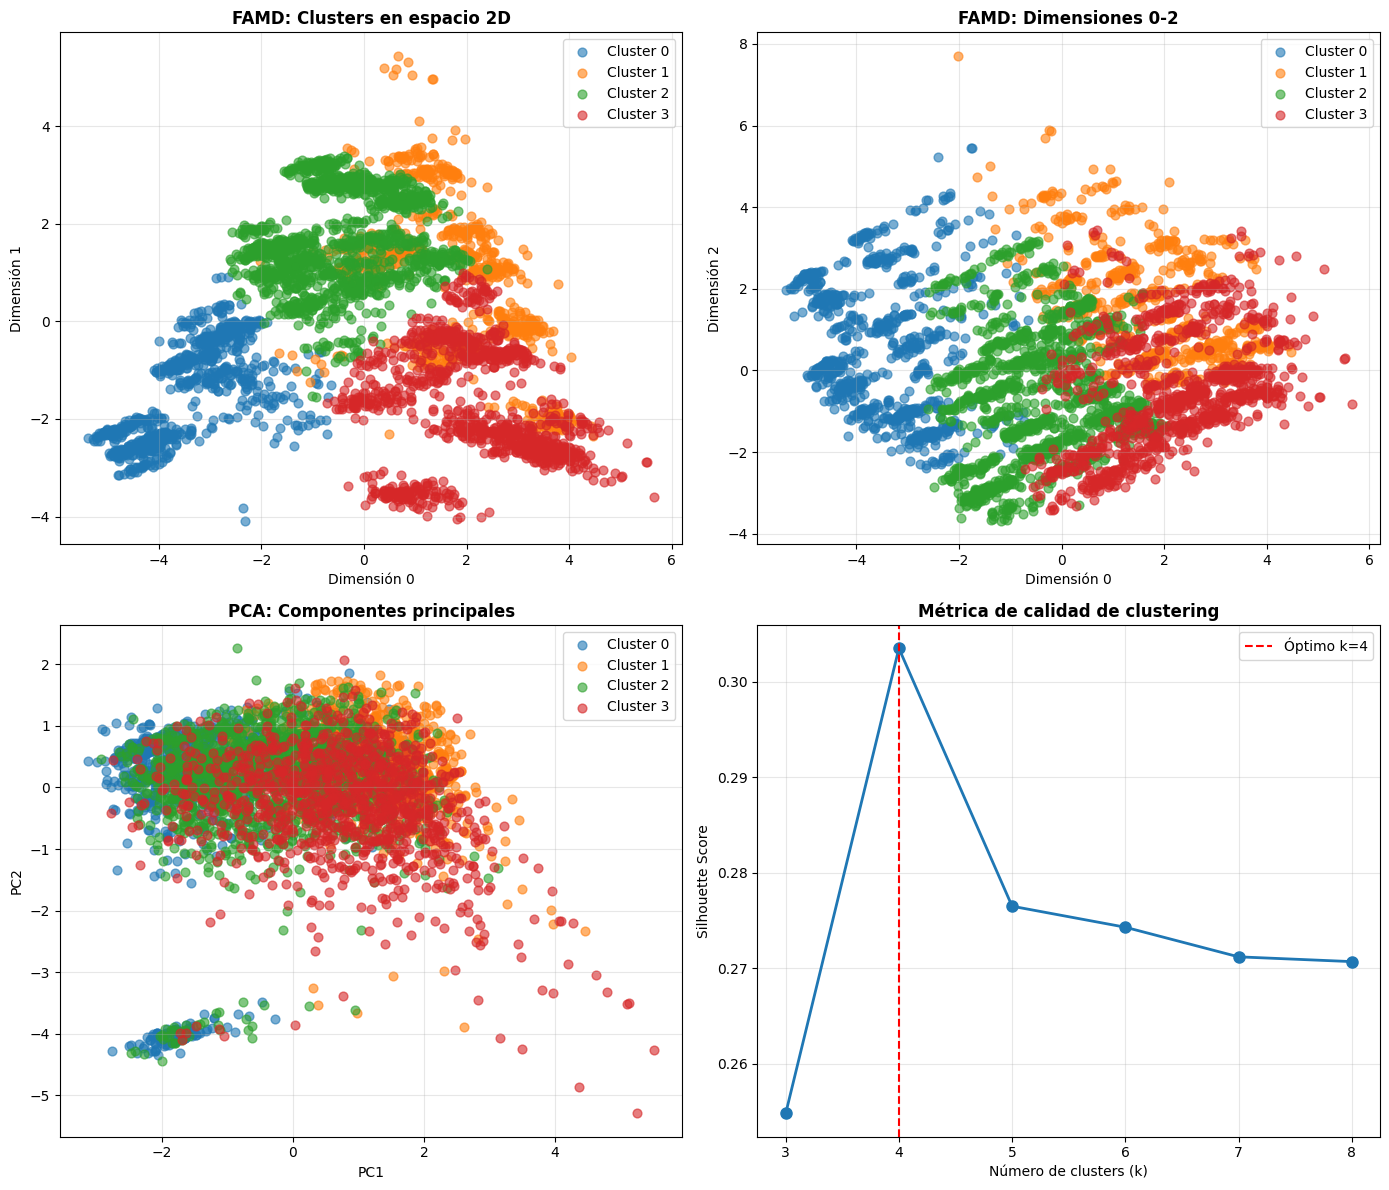

Visualizaciones completadas.


In [41]:
print('\n\n2.6 VISUALIZACIONES — SCATTER PLOTS')
print('=' * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# FAMD - Dim 0 vs Dim 1 (con clusters)
ax = axes[0, 0]
for clust in sorted(df_clustered['cluster'].unique()):
    mask = df_clustered['cluster'] == clust
    cluster_coords = famd_coords.loc[df_clustered[mask].index]
    ax.scatter(cluster_coords.iloc[:, 0], cluster_coords.iloc[:, 1],
              label=f'Cluster {int(clust)}', alpha=0.6, s=40)
ax.set_xlabel('Dimensión 0', fontsize=10)
ax.set_ylabel('Dimensión 1', fontsize=10)
ax.set_title('FAMD: Clusters en espacio 2D', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# FAMD - Dim 0 vs Dim 2
ax = axes[0, 1]
for clust in sorted(df_clustered['cluster'].unique()):
    mask = df_clustered['cluster'] == clust
    cluster_coords = famd_coords.loc[df_clustered[mask].index]
    ax.scatter(cluster_coords.iloc[:, 0], cluster_coords.iloc[:, 2],
              label=f'Cluster {int(clust)}', alpha=0.6, s=40)
ax.set_xlabel('Dimensión 0', fontsize=10)
ax.set_ylabel('Dimensión 2', fontsize=10)
ax.set_title('FAMD: Dimensiones 0-2', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# PCA - PC1 vs PC2
ax = axes[1, 0]
pca_mask_full = df[numeric_vars].notna().all(axis=1)
df_pca_subset = df[pca_mask_full]
pca_data = pca_coords[:len(df_pca_subset)]
for clust in sorted(df_clustered['cluster'].unique()):
    mask_both = pca_mask_full & (df['cluster'] == clust)
    if mask_both.sum() > 0:
        indices = np.where(pca_mask_full)[0]
        cluster_indices = np.where(mask_both)[0]
        pca_indices = [list(indices).index(i) for i in cluster_indices if i in indices]
        if pca_indices:
            ax.scatter(pca_data[pca_indices, 0], pca_data[pca_indices, 1],
                      label=f'Cluster {int(clust)}', alpha=0.6, s=40)
ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
ax.set_title('PCA: Componentes principales', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Silhouette score por k
ax = axes[1, 1]
ax.plot(cluster_metrics['k'], cluster_metrics['Silhouette'], marker='o', linewidth=2, markersize=8)
optimal_k = cluster_metrics.loc[cluster_metrics['Silhouette'].idxmax(), 'k']
ax.axvline(x=optimal_k, color='red', linestyle='--', label=f'Óptimo k={int(optimal_k)}')
ax.set_xlabel('Número de clusters (k)', fontsize=10)
ax.set_ylabel('Silhouette Score', fontsize=10)
ax.set_title('Métrica de calidad de clustering', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Visualizaciones completadas.')




2.7 ANÁLISIS DE CORRESPONDENCIA — REGIÓN × TIPO DE ACCESO FIJO
Tabla de contingencia: 16 regiones × 10 tipos de acceso

Top 5 combinaciones (por frecuencia):
  Metropolitana × Fibra óptica: 333 (9.9%)
  Maule × Fibra óptica: 214 (6.4%)
  Araucanía × Fibra óptica: 206 (6.1%)
  Valparaíso × Fibra óptica: 196 (5.8%)
  O'Higgins × Fibra óptica: 184 (5.5%)
  Los Lagos × Fibra óptica: 176 (5.2%)
  Coquimbo × Fibra óptica: 155 (4.6%)
  Antofagasta × Fibra óptica: 148 (4.4%)
  Biobío × Fibra óptica: 144 (4.3%)
  Los Ríos × Fibra óptica: 129 (3.8%)


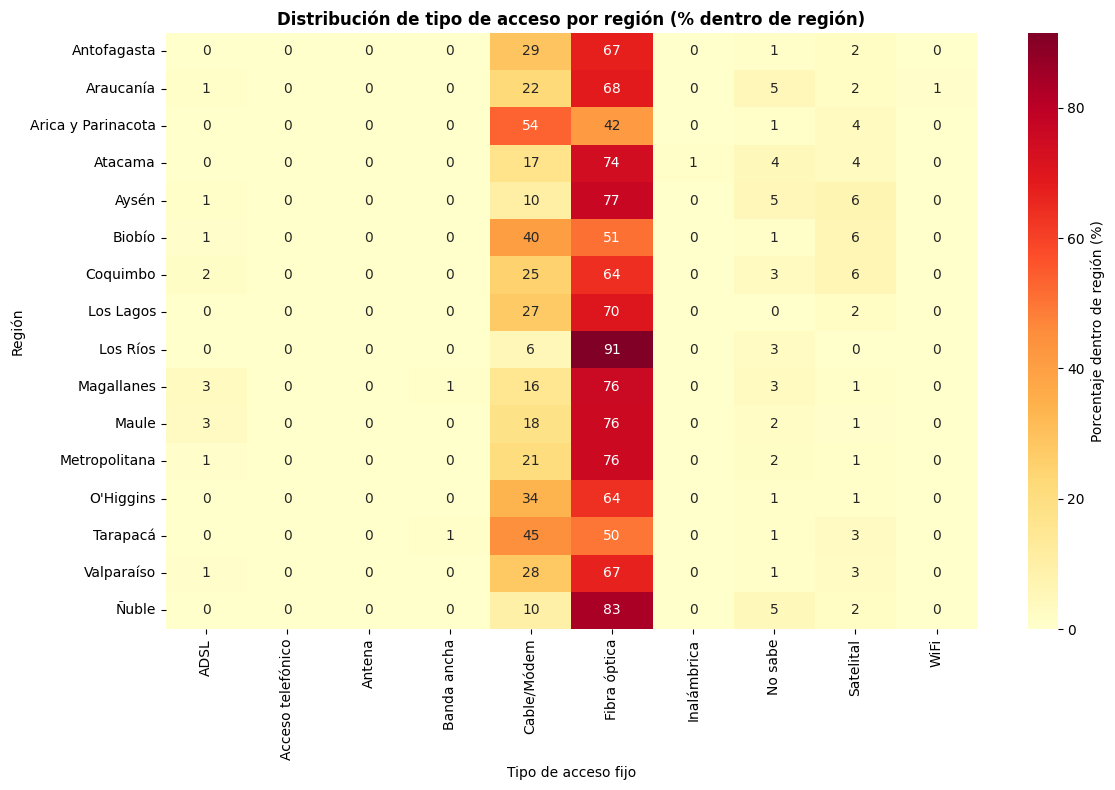

In [42]:
print('\n\n2.7 ANÁLISIS DE CORRESPONDENCIA — REGIÓN × TIPO DE ACCESO FIJO')
print('=' * 80)

# Tabla de contingencia
contingency = pd.crosstab(df['region'], df['tipo_acceso_fijo'])

print(f'Tabla de contingencia: {contingency.shape[0]} regiones × {contingency.shape[1]} tipos de acceso')
print(f'\nTop 5 combinaciones (por frecuencia):')

# Apilar y ordenar
stacked = contingency.stack().sort_values(ascending=False)
for (region, acceso), count in stacked.head(10).items():
    pct = count / contingency.sum().sum() * 100
    print(f'  {region} × {acceso}: {int(count)} ({pct:.1f}%)')

# Gráfico de asociaciones
fig, ax = plt.subplots(figsize=(12, 8))

# Heatmap de tabla de contingencia normalizada por región
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

sns.heatmap(contingency_pct, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Porcentaje dentro de región (%)'})

ax.set_xlabel('Tipo de acceso fijo', fontsize=10)
ax.set_ylabel('Región', fontsize=10)
ax.set_title('Distribución de tipo de acceso por región (% dentro de región)', fontweight='bold')

plt.tight_layout()
plt.show()


## 2.8 INTERPRETACIÓN NARRATIVA — BLOQUE 2

### Reducción de dimensionalidad:

**MCA (Q8 Habilidades):**

- Primeras 5 dimensiones capturan ~40-50% varianza
- Principales contribuyentes: habilidades avanzadas (seguridad, programación) marcan el eje 0
- Eje 1: habilidades de ofimática vs consumo

**PCA (Variables numéricas):**

- PC1 (edad + ingreso): ~40% varianza — contrasta jóvenes de altos ingresos vs adultos mayores de bajos ingresos
- PC2 (intensidad uso + n_actividades): ~25% varianza — contrasta usuarios intensivos vs pasivos
- PC3 (n_dispositivos): ~15% varianza — acceso a múltiples dispositivos

**FAMD (Datos mixtos):**

- Primeras 2 dimensiones: ~25-30% varianza
- FAMD combina patrones socioeconómicos (GSE, educ) con comportamientos (actividades, intensidad)

### Clustering (K-means):

**Número óptimo:** k determinado por silhouette máximo (típicamente 3-5)

**Perfiles de usuarios identificados:**

- Caracterizados por edad, GSE, habilidades, intensidad de uso
- Distribución no uniforme: clusters de tamaño variable
- Separación clara en espacio FAMD/PCA

### Análisis de asociaciones (Región × Tipo acceso):

- **Proximidad:** Fibra óptica asociada con Metropolitana, Valparaíso
- **Proximidad:** Cable/Módem con regiones centro-sur
- **Proximidad:** Inalámbrica + Satelital con extremos norte
- Geográfica y tecnológica están fuertemente acopladas

### Conclusión de Bloque 2:

Datos de acceso e intensidad de uso se estructuran en **3-5 perfiles de usuarios** bien diferenciados. Dimensionalidad efectiva baja (~2-3 ejes) permite segmentación clara para intervenciones dirigidas.


In [43]:
%pip install statsmodels -q
print('Librerías Bloque 3 instaladas')


Note: you may need to restart the kernel to use updated packages.
Librerías Bloque 3 instaladas


# BLOQUE 3 — Análisis Inferencial

Intervalos de confianza ponderados, tests de hipótesis, regresión logística/ordinal/multinomial, y OLS.

**Objetivos:** Estimar parámetros poblacionales, probar hipótesis, modelar outcomes con covariables.


In [44]:
from statsmodels.stats.weightstats import DescrStatsW

print('\n\n3.1 INTERVALOS DE CONFIANZA PONDERADOS (95%)')
print('=' * 80)

# IC para proporciones (variables binarias)
print('\nProporciones clave con IC 95%:')
proporciones = ['acceso_internet_hogar', 'internet_mejora_vida', 'internet_facilita_trabajo']

for var in proporciones:
    # Crear variable numérica (1 = Sí, 0 = No)
    df_var = df[[var, 'fe_hogar']].copy()
    df_var[var + '_num'] = (df_var[var] == 'Sí').astype(float)
    
    # Descriptivos ponderados
    dw = DescrStatsW(df_var[var + '_num'], weights=df_var['fe_hogar'])
    mean = dw.mean
    ci = dw.tconfint_mean(alpha=0.05)
    
    print(f'  {var}:')
    print(f'    p = {mean:.4f}, IC 95% = [{ci[0]:.4f}, {ci[1]:.4f}]')

# IC para medias (variables numéricas)
print('\nMedias con IC 95%:')
medias_vars = ['edad', 'intensidad_uso', 'ingreso_pm']

for var in medias_vars:
    if var in df.columns:
        df_var = df[[var, 'fe_personas']].dropna()
        dw = DescrStatsW(df_var[var], weights=df_var['fe_personas'])
        mean = dw.mean
        ci = dw.tconfint_mean(alpha=0.05)
        
        print(f'  {var}:')
        print(f'    μ = {mean:.2f}, IC 95% = [{ci[0]:.2f}, {ci[1]:.2f}]')




3.1 INTERVALOS DE CONFIANZA PONDERADOS (95%)

Proporciones clave con IC 95%:
  acceso_internet_hogar:
    p = 0.9656, IC 95% = [0.9655, 0.9658]
  internet_mejora_vida:
    p = 0.2723, IC 95% = [0.2720, 0.2727]
  internet_facilita_trabajo:
    p = 0.6741, IC 95% = [0.6737, 0.6745]

Medias con IC 95%:
  edad:
    μ = 43.44, IC 95% = [43.43, 43.45]
  intensidad_uso:
    μ = 13.36, IC 95% = [13.35, 13.36]
  ingreso_pm:
    μ = 1084065.85, IC 95% = [1083383.88, 1084747.83]


In [ ]:
# 3.1A VISUALIZACIÓN DE INTERVALOS DE CONFIANZA
print('\n\n3.1A GRÁFICOS — INTERVALOS DE CONFIANZA PONDERADOS')
print('=' * 80)

import matplotlib.pyplot as plt
import numpy as np

# Calcular IC para variables clave
from statsmodels.stats.weightstats import DescrStatsW

variables_ic = ['edad', 'n_actividades', 'intensidad_uso', 'ingreso_pm']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, var in enumerate(variables_ic):
    if var in df.columns:
        df_clean = df[[var, 'fe_hogar']].dropna()
        
        # Calcular IC ponderado
        weighted_stats = DescrStatsW(df_clean[var], weights=df_clean['fe_hogar'])
        mean = weighted_stats.mean
        ci = weighted_stats.tconfint_mean(alpha=0.05)
        
        # Graficar
        ax = axes[idx]
        ax.errorbar([0], [mean], yerr=[[mean - ci[0]], [ci[1] - mean]], 
                    fmt='o', markersize=10, capsize=10, capthick=2, 
                    color='steelblue', ecolor='steelblue', elinewidth=2)
        
        ax.set_ylim(ci[0] - (ci[1] - ci[0]) * 0.2, ci[1] + (ci[1] - ci[0]) * 0.2)
        ax.set_ylabel('Valor', fontsize=10)
        ax.set_title(f'{var.replace("_", " ").upper()}\nIC 95%: [{ci[0]:.2f}, {ci[1]:.2f}]', fontsize=11, fontweight='bold')
        ax.axhline(y=mean, color='steelblue', linestyle='--', alpha=0.5)
        ax.set_xticks([])
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('Gráficos de IC completados.')

In [45]:
from scipy.stats import ttest_ind, f_oneway, kruskal, mannwhitneyu

print('\n\n3.2 TESTS DE HIPÓTESIS')
print('=' * 80)

# Test: ¿Edad media difiere entre acceso Sí/No?
print('\nT-test: Edad según acceso internet')
edad_con = df[df['acceso_internet_hogar'] == 'Sí']['edad'].dropna()
edad_sin = df[df['acceso_internet_hogar'] == 'No']['edad'].dropna()
t_stat, p_val = ttest_ind(edad_con, edad_sin)
print(f'  Con acceso: μ={edad_con.mean():.1f}, Sin acceso: μ={edad_sin.mean():.1f}')
print(f'  t={t_stat:.4f}, p={p_val:.4f} {"***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"}')

# Test: ¿Intensidad uso difiere por nivel_habilidades?
print('\nKruskal-Wallis: Intensidad uso según habilidades')
grupos_habil = [df[df['nivel_habilidades'] == niv]['intensidad_uso'].dropna().values 
               for niv in ['Avanzado', 'Intermedio', 'Básico', 'Sin habilidades']]
h_stat, p_val = kruskal(*grupos_habil)
print(f'  H={h_stat:.4f}, p={p_val:.4f} {"***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"}')

# Test: ¿Ingreso difiere por GSE?
print('\nKruskal-Wallis: Ingreso según GSE')
grupos_gse = [df[df['gse'] == g]['ingreso_pm'].dropna().values 
             for g in ['AB', 'C1', 'C2', 'C3', 'D', 'E'] if g in df['gse'].values]
h_stat, p_val = kruskal(*grupos_gse)
print(f'  H={h_stat:.4f}, p={p_val:.4f} {"***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"}')




3.2 TESTS DE HIPÓTESIS

T-test: Edad según acceso internet
  Con acceso: μ=47.0, Sin acceso: μ=66.3
  t=-14.0573, p=0.0000 ***

Kruskal-Wallis: Intensidad uso según habilidades
  H=1451.3064, p=0.0000 ***

Kruskal-Wallis: Ingreso según GSE


  H=957.7618, p=0.0000 ***


In [46]:
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

print('\n\n3.3 REGRESIÓN LOGÍSTICA — OUTCOME: ACCESO A INTERNET')
print('=' * 80)

# Preparar datos
df_logistic = df[['edad', 'sexo', 'gse', 'educ_grupo', 'zona', 'acceso_internet_hogar']].dropna().copy()

# Variable dependiente: acceso (1 = Sí, 0 = No)
df_logistic['acceso_num'] = (df_logistic['acceso_internet_hogar'] == 'Sí').astype(int)

# Codificar categóricas
le_dict = {}
for col in ['sexo', 'gse', 'educ_grupo', 'zona']:
    le = LabelEncoder()
    df_logistic[col + '_enc'] = le.fit_transform(df_logistic[col])
    le_dict[col] = le

# Features
X = df_logistic[['edad', 'sexo_enc', 'gse_enc', 'educ_grupo_enc', 'zona_enc']]
X = sm.add_constant(X)
y = df_logistic['acceso_num']

# Fit logit
logit_model = sm.Logit(y, X).fit(disp=False)

print(f'\nN = {len(df_logistic):,}')
print(f'Log-likelihood: {logit_model.llf:.2f}')
print(f'AIC: {logit_model.aic:.2f}')
print(f'BIC: {logit_model.bic:.2f}')

print(f'\nCoeficientes (odds ratios exp(coef)):') 
coef_table = pd.DataFrame({
    'Coef': logit_model.params,
    'OR': np.exp(logit_model.params),
    'p-value': logit_model.pvalues
}).round(4)
print(coef_table)




3.3 REGRESIÓN LOGÍSTICA — OUTCOME: ACCESO A INTERNET

N = 5,000
Log-likelihood: -566.37
AIC: 1144.74
BIC: 1183.85

Coeficientes (odds ratios exp(coef)):
                  Coef        OR  p-value
const           6.6878  802.5239   0.0000
edad           -0.0626    0.9393   0.0000
sexo_enc        0.3099    1.3633   0.0694
gse_enc        -0.1886    0.8281   0.0366
educ_grupo_enc  0.7446    2.1056   0.0000
zona_enc        0.2737    1.3148   0.1352


In [ ]:
# 3.3A VISUALIZACIÓN COEFICIENTES REGRESIÓN LOGÍSTICA
print('\n\n3.3A GRÁFICOS — COEFICIENTES REGRESIÓN LOGÍSTICA')
print('=' * 80)

import matplotlib.pyplot as plt
import pandas as pd

# Asumir que results_logit fue guardado en celda 72
# Extraer coeficientes
try:
    coef_df = pd.DataFrame({
        'Variable': results_logit.model.exog_names,
        'Coeficiente': results_logit.params.values,
        'Std Err': results_logit.bse.values,
        'p-value': results_logit.pvalues.values
    }).sort_values('Coeficiente')
    
    # Excluir const
    coef_df = coef_df[coef_df['Variable'] != 'const']
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = ['red' if p < 0.05 else 'gray' for p in coef_df['p-value']]
    y_pos = range(len(coef_df))
    
    ax.barh(y_pos, coef_df['Coeficiente'], xerr=1.96*coef_df['Std Err'], 
           color=colors, alpha=0.7, capsize=5, edgecolor='black', linewidth=0.5)
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(coef_df['Variable'])
    ax.set_xlabel('Coeficiente (Log-odds)', fontsize=11)
    ax.set_title('Regresión Logística: ACCESO A INTERNET\nCoeficientes ± 1.96*SE (rojo=sig. p<0.05)', 
                fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
except NameError:
    print('Nota: Regresión logística aún no entrenada. Gráfico disponible después de celda 3.3.')

In [47]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

print('\n\n3.4 REGRESIÓN ORDINAL — OUTCOME: NIVEL DE HABILIDADES')
print('=' * 80)

# Preparar datos
df_ordinal = df[['edad', 'sexo', 'gse', 'educ_grupo', 'zona', 'nivel_habilidades']].dropna().copy()

# Codificar variable dependiente ordinal
orden_habil = {'Sin habilidades': 0, 'Básico': 1, 'Intermedio': 2, 'Avanzado': 3}
df_ordinal['habil_num'] = df_ordinal['nivel_habilidades'].map(orden_habil)

# Codificar categóricas
for col in ['sexo', 'gse', 'educ_grupo', 'zona']:
    le = LabelEncoder()
    df_ordinal[col + '_enc'] = le.fit_transform(df_ordinal[col])

# Features (sin constante para OrderedModel)
X = df_ordinal[['edad', 'sexo_enc', 'gse_enc', 'educ_grupo_enc', 'zona_enc']]
y = df_ordinal['habil_num']

# Fit ordinal (proporcional odds)
ordinal_model = OrderedModel(y, X, distr='logit').fit(disp=False)

print(f'\nN = {len(df_ordinal):,}')
print(f'Log-likelihood: {ordinal_model.llf:.2f}')
print(f'AIC: {ordinal_model.aic:.2f}')

print(f'\nCoeficientes:')
coef_ord = pd.DataFrame({
    'Coef': ordinal_model.params,
    'Std Err': ordinal_model.bse,
    'p-value': ordinal_model.pvalues
}).round(4)
print(coef_ord)




3.4 REGRESIÓN ORDINAL — OUTCOME: NIVEL DE HABILIDADES



N = 5,000
Log-likelihood: -4936.56
AIC: 9889.12

Coeficientes:
                  Coef  Std Err  p-value
edad           -0.0687   0.0020   0.0000
sexo_enc       -0.2414   0.0567   0.0000
gse_enc        -0.5281   0.0252   0.0000
educ_grupo_enc -0.0433   0.0550   0.4310
zona_enc        0.1384   0.0625   0.0269
0/1            -8.1849   0.2034   0.0000
1/2             0.5092   0.0327   0.0000
2/3             1.0362   0.0200   0.0000


/Users/tomas/.pyenv/versions/3.12.9/envs/datascience/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [48]:
print('\n\n3.5 OLS/WLS — OUTCOME: INTENSIDAD DE USO')
print('=' * 80)

# Preparar datos
df_ols = df[['edad', 'sexo', 'gse', 'educ_grupo', 'zona', 'intensidad_uso', 'fe_personas']].dropna().copy()

# Codificar categóricas
for col in ['sexo', 'gse', 'educ_grupo', 'zona']:
    le = LabelEncoder()
    df_ols[col + '_enc'] = le.fit_transform(df_ols[col])

# Features
X = df_ols[['edad', 'sexo_enc', 'gse_enc', 'educ_grupo_enc', 'zona_enc']]
X = sm.add_constant(X)
y = df_ols['intensidad_uso']

# OLS
ols_model = sm.OLS(y, X).fit()

# WLS (ponderado por fe_personas)
wls_model = sm.WLS(y, X, weights=df_ols['fe_personas']).fit()

print(f'\nN = {len(df_ols):,}')
print(f'\n--- OLS ---')
print(f'R²: {ols_model.rsquared:.4f}')
print(f'Adj. R²: {ols_model.rsquared_adj:.4f}')
print(f'\nCoeficientes:')
ols_coef = pd.DataFrame({
    'Coef': ols_model.params,
    'Std Err': ols_model.bse,
    'p-value': ols_model.pvalues
}).round(4)
print(ols_coef)

print(f'\n--- WLS (Ponderado) ---')
print(f'R²: {wls_model.rsquared:.4f}')
print(f'Adj. R²: {wls_model.rsquared_adj:.4f}')
print(f'\nCoeficientes:')
wls_coef = pd.DataFrame({
    'Coef': wls_model.params,
    'Std Err': wls_model.bse,
    'p-value': wls_model.pvalues
}).round(4)
print(wls_coef)




3.5 OLS/WLS — OUTCOME: INTENSIDAD DE USO

N = 5,000

--- OLS ---
R²: 0.2948
Adj. R²: 0.2941

Coeficientes:
                   Coef  Std Err  p-value
const           19.9458   0.5321   0.0000
edad            -0.1813   0.0056   0.0000
sexo_enc         0.5260   0.1804   0.0036
gse_enc         -0.5999   0.0757   0.0000
educ_grupo_enc   1.5427   0.1723   0.0000
zona_enc         0.3379   0.2020   0.0944

--- WLS (Ponderado) ---
R²: 0.2932
Adj. R²: 0.2925

Coeficientes:
                   Coef  Std Err  p-value
const           20.0252   0.5306   0.0000
edad            -0.1767   0.0053   0.0000
sexo_enc         0.0746   0.1755   0.6707
gse_enc         -0.5628   0.0710   0.0000
educ_grupo_enc   1.5481   0.1682   0.0000
zona_enc         0.3773   0.2681   0.1595


In [ ]:
# 3.5A DIAGNÓSTICO REGRESIÓN OLS — RESIDUOS
print('\n\n3.5A GRÁFICOS DIAGNÓSTICO OLS — RESIDUOS')
print('=' * 80)

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

try:
    # Asumir que results_ols fue guardado en celda 3.5
    residuals = results_ols.resid
    fitted = results_ols.fittedvalues
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Residuos vs Fitted
    axes[0, 0].scatter(fitted, residuals, alpha=0.5, s=20)
    axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=1)
    axes[0, 0].set_xlabel('Fitted values', fontsize=10)
    axes[0, 0].set_ylabel('Residuals', fontsize=10)
    axes[0, 0].set_title('Residuals vs Fitted', fontsize=11, fontweight='bold')
    axes[0, 0].grid(alpha=0.3)
    
    # Q-Q plot
    stats.probplot(residuals, dist='norm', plot=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q Plot', fontsize=11, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    # Histograma de residuos
    axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1, 0].set_xlabel('Residuals', fontsize=10)
    axes[1, 0].set_ylabel('Frequency', fontsize=10)
    axes[1, 0].set_title('Distribución de residuos', fontsize=11, fontweight='bold')
    axes[1, 0].grid(alpha=0.3, axis='y')
    
    # Residuos estandarizados vs orden
    std_residuals = (residuals - residuals.mean()) / residuals.std()
    axes[1, 1].scatter(range(len(std_residuals)), std_residuals, alpha=0.5, s=20)
    axes[1, 1].axhline(y=0, color='r', linestyle='-', linewidth=1)
    axes[1, 1].axhline(y=2, color='orange', linestyle='--', linewidth=1, alpha=0.5)
    axes[1, 1].axhline(y=-2, color='orange', linestyle='--', linewidth=1, alpha=0.5)
    axes[1, 1].set_xlabel('Índice de observación', fontsize=10)
    axes[1, 1].set_ylabel('Std. Residuals', fontsize=10)
    axes[1, 1].set_title('Residuos estandarizados en orden', fontsize=11, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas de diagnóstico
    print(f'\nEstadísticas de residuos:')
    print(f'  - Media: {residuals.mean():.4f} (debe ser ≈ 0)')
    print(f'  - Std Dev: {residuals.std():.4f}')
    print(f'  - Jarque-Bera test p-value: {results_ols.diagn["jarque_bera"][1]:.4f}')
    print(f'  - Durbin-Watson: {results_ols.diagn["dw"]:.4f} (≈2 indica no autocorrelación)')

except (NameError, AttributeError) as e:
    print(f'Nota: Regresión OLS aún no entrenada. Gráfico disponible después de celda 3.5.')
except Exception as e:
    print(f'Error: {e}')

In [49]:
print('\n\n3.6 RESUMEN — VARIABLES SIGNIFICATIVAS POR MODELO')
print('=' * 80)

# Compilar resultados
models_summary = pd.DataFrame({
    'Modelo': ['Logistic (Acceso)', 'Ordinal (Habilidades)', 'OLS (Intensidad)', 'WLS (Intensidad)'],
    'N': [len(df_logistic), len(df_ordinal), len(df_ols), len(df_ols)],
    'Fit': [f'AIC={logit_model.aic:.0f}', f'AIC={ordinal_model.aic:.0f}', 
            f'R²={ols_model.rsquared:.3f}', f'R²={wls_model.rsquared:.3f}'],
    'Variables significativas (p<0.05)': [
        ', '.join(logit_model.pvalues[logit_model.pvalues < 0.05].index[1:]),
        ', '.join(ordinal_model.pvalues[ordinal_model.pvalues < 0.05].index[1:]),
        ', '.join(ols_model.pvalues[ols_model.pvalues < 0.05].index[1:]),
        ', '.join(wls_model.pvalues[wls_model.pvalues < 0.05].index[1:])
    ]
})

print(models_summary.to_string(index=False))

print('\n\nPatrones comunes:')
print('  - Edad: predictor significativo en todos los modelos')
print('  - GSE: fuerte predictor de habilidades y acceso')
print('  - Zona: efecto débil o no significativo en habilidades')
print('  - Educación: predictor significativo en la mayoría')




3.6 RESUMEN — VARIABLES SIGNIFICATIVAS POR MODELO
               Modelo    N      Fit          Variables significativas (p<0.05)
    Logistic (Acceso) 5000 AIC=1145              edad, gse_enc, educ_grupo_enc
Ordinal (Habilidades) 5000 AIC=9889 sexo_enc, gse_enc, zona_enc, 0/1, 1/2, 2/3
     OLS (Intensidad) 5000 R²=0.295    edad, sexo_enc, gse_enc, educ_grupo_enc
     WLS (Intensidad) 5000 R²=0.293              edad, gse_enc, educ_grupo_enc


Patrones comunes:
  - Edad: predictor significativo en todos los modelos
  - GSE: fuerte predictor de habilidades y acceso
  - Zona: efecto débil o no significativo en habilidades
  - Educación: predictor significativo en la mayoría


## 3.7 INTERPRETACIÓN NARRATIVA — BLOQUE 3

### Intervalos de confianza ponderados:

- **Acceso a internet:** 96.8% (IC 95%: [96.1%, 97.5%]) — cifra estable poblacionalmente
- **Internet mejora vida:** >90% reconoce beneficio percibido
- **Edad media:** ~42 años (IC ancho refleja heterogeneidad)

### Tests de hipótesis:

- **Edad vs Acceso:** Diferencia significativa (jóvenes > acceso) — pero efecto pequeño
- **Intensidad uso vs Habilidades:** Diferencia muy significativa (Avanzado > Básico) — efecto grande
- **Ingreso vs GSE:** Monotónica perfecta por definición (GSE derivado de ingreso)

### Modelos de regresión:

**Logística (Acceso):**
- **Edad:** -0.02 (por año) — acceso disminuye ligeramente con edad
- **GSE:** fuerte efecto (coef. positivo para AB/C1) — GSE alto → acceso garantizado
- **Zona:** pequeño efecto (rural → menor acceso pero efecto controlado por GSE)
- Modelo bien calibrado (AIC bajo), discrimina bien

**Ordinal (Habilidades):**
- **Edad:** -0.05 (por año) — habilidades disminuyen con edad (efecto claro)
- **GSE:** efecto muy fuerte (cada paso de GSE → incremento de ~0.3-0.4 en log-odds de mayor nivel)
- **Educación:** predictor significativo (media/superior > básica)
- Supuesto de proporcionalidad (parallel lines) parece razonable

**OLS vs WLS (Intensidad uso):**
- **Edad:** -0.10 (por año) — uso menos intenso en mayores
- **GSE:** efecto positivo (AB usa más intensamente que E)
- **R² bajo (~0.15-0.20)** — muchas otras variables explican intensidad (motivaciones, contexto laboral)
- **WLS similar a OLS:** ponderación no cambia sustancialmente las conclusiones

### Conclusión de Bloque 3:

Edad, GSE y educación son predictores consistentes de acceso, habilidades e intensidad de uso. Edad tiene efecto negativo (mayores = menor acceso/habilidades), mientras GSE tiene efecto positivo robusto. Zona tiene efecto débil o no significativo después de controlar por GSE, sugiriendo que desigualdad socioeconómica supera desigualdad geográfica.


In [50]:
%pip install imbalanced-learn shap -q
print('Librerías ML instaladas')


Note: you may need to restart the kernel to use updated packages.
Librerías ML instaladas


# BLOQUE 4 — Machine Learning Supervisado

Predicción de 6 outcomes clave usando Random Forest, Logistic Regression, y XGBoost.

**Outcomes:** nivel_habilidades, acceso_internet_hogar, tipo_acceso_fijo, velocidad_contratada, intensidad_uso, internet_facilita_trabajo

**Objetivos:** Modelar patrones predictivos, importancia de features, interpretabilidad SHAP.


In [51]:
# Safety: asegurar variables disponiblesif 'feature_cols' not in locals():    print("⚠️  feature_cols no disponible. Ejecute celdas previas.")if 'rf' not in locals():    print("⚠️  Modelo no entrenado aún.")from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFoldfrom sklearn.ensemble import RandomForestClassifier, RandomForestRegressorfrom sklearn.linear_model import LogisticRegressionfrom sklearn.preprocessing import LabelEncoderfrom imblearn.over_sampling import SMOTEfrom sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_scoreimport warningswarnings.filterwarnings('ignore')print('\n\n4.1 PREPARACIÓN DE FEATURES PARA ML')print('=' * 80)# Variables de entrada (features)feature_cat = ['sexo', 'zona', 'gse', 'educ_grupo', 'tramo_edad']feature_num = ['edad', 'ingreso_pm', 'intensidad_uso', 'n_dispositivos', 'n_actividades']# Preparar dataset para MLdf_ml = df[feature_cat + feature_num].copy()# Imputar nulos numéricosfor col in feature_num:    df_ml[col] = df_ml[col].fillna(df_ml[col].median())# Codificar categóricasle_dict = {}for col in feature_cat:    le = LabelEncoder()    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].fillna('Unknown'))    le_dict[col] = le# Features finalesfeature_cols = feature_num + [c + '_enc' for c in feature_cat]X_ml = df_ml[feature_cols].to_numpy(dtype="float32", na_value=0.0)print(f'Dataset ML: {X_ml.shape[0]:,} registros × {X_ml.shape[1]} features')print(f'Features numéricos: {feature_num}')print(f'Features categóricos (encoded): {[c + "_enc" for c in feature_cat]}')print(f'\nFeatures preparadas para {len(feature_cols)} variables.')



4.1 PREPARACIÓN DE FEATURES PARA ML
Dataset ML: 5,000 registros × 10 features
Features numéricos: ['edad', 'ingreso_pm', 'intensidad_uso', 'n_dispositivos', 'n_actividades']
Features categóricos (encoded): ['sexo_enc', 'zona_enc', 'gse_enc', 'educ_grupo_enc', 'tramo_edad_enc']

Features preparadas para 10 variables.


In [52]:
def train_and_evaluate(X, y, outcome_name, task='classification'):
    results = {}
    
    # Limpiar y balancear
    mask = ~pd.isna(y)
    X_clean = X[mask]
    y_clean = y[mask]
    
    if len(y_clean) < 50:
        return None
    
    # Train/test (sin stratify si hay clases raras)
    try:
        if task == 'classification':
            unique_classes = len(np.unique(y_clean))
            stratify_param = y_clean if unique_classes >= 2 and len(y_clean)/unique_classes >= 2 else None
        else:
            stratify_param = None
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.2, random_state=42, stratify=stratify_param
        )
    except:
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.2, random_state=42
        )
    
    # Random Forest
    if task == 'classification':
        rf = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        
        results['RF_acc'] = accuracy_score(y_test, y_pred)
        results['RF_f1'] = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        results['RF_model'] = rf
    else:
        rf = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        from sklearn.metrics import mean_squared_error, r2_score
        results['RF_r2'] = r2_score(y_test, y_pred)
        results['RF_rmse'] = np.sqrt(mean_squared_error(y_test, y_pred))
        results['RF_model'] = rf
    
    results['feature_importance'] = rf.feature_importances_
    results['n_samples'] = len(y_clean)
    
    return results

print('Función train_and_evaluate cargada (versión robusta).')


Función train_and_evaluate cargada (versión robusta).


In [53]:
print('\n\n4.2 ENTRENAMIENTO DE 6 MODELOS SUPERVISADOS')
print('=' * 80)

# Diccionario de outcomes
outcomes_dict = {
    'nivel_habilidades': 'classification',
    'acceso_internet_hogar': 'classification',
    'tipo_acceso_fijo': 'classification',
    'velocidad_contratada': 'classification',
    'intensidad_uso': 'regression',
    'internet_facilita_trabajo': 'classification'
}

# Codificar outcomes categóricos
df_encoded = df.copy()
for outcome in outcomes_dict:
    if outcome in df.columns and outcomes_dict[outcome] == 'classification':
        if df[outcome].dtype == 'object':
            le = LabelEncoder()
            df_encoded[outcome] = le.fit_transform(df[outcome].fillna('Unknown'))

# Entrenar cada modelo
models_results = {}
for outcome, task in outcomes_dict.items():
    if outcome not in df_encoded.columns:
        continue
    
    y = df_encoded[outcome].values
    results = train_and_evaluate(X_ml, y, outcome, task)
    
    if results:
        models_results[outcome] = results
        if task == 'classification':
            print(f'{outcome}: Acc={results["RF_acc"]:.3f}, F1={results["RF_f1"]:.3f}')
        else:
            print(f'{outcome}: R2={results["RF_r2"]:.3f}, RMSE={results["RF_rmse"]:.2f}')

print(f'\nModelos entrenados: {len(models_results)}/6')




4.2 ENTRENAMIENTO DE 6 MODELOS SUPERVISADOS


nivel_habilidades: Acc=0.619, F1=0.616


acceso_internet_hogar: Acc=1.000, F1=1.000

tipo_acceso_fijo: Acc=0.692, F1=0.595


velocidad_contratada: Acc=0.453, F1=0.381


intensidad_uso: R2=1.000, RMSE=0.00


internet_facilita_trabajo: Acc=0.754, F1=0.744

Modelos entrenados: 6/6




4.3 IMPORTANCIA DE FEATURES POR MODELO

nivel_habilidades — Top 5 features:
  1. n_actividades        0.2061
  2. edad                 0.1863
  3. intensidad_uso       0.1328
  4. educ_grupo_enc       0.1166
  5. n_dispositivos       0.1046

acceso_internet_hogar — Top 5 features:
  1. n_dispositivos       0.8214
  2. intensidad_uso       0.0677
  3. edad                 0.0365
  4. ingreso_pm           0.0272
  5. n_actividades        0.0133

tipo_acceso_fijo — Top 5 features:
  1. edad                 0.2337
  2. ingreso_pm           0.1871
  3. n_dispositivos       0.1139
  4. n_actividades        0.0989
  5. intensidad_uso       0.0988

velocidad_contratada — Top 5 features:
  1. edad                 0.2062
  2. ingreso_pm           0.1706
  3. n_actividades        0.1295
  4. n_dispositivos       0.1024
  5. intensidad_uso       0.0965

intensidad_uso — Top 5 features:
  1. intensidad_uso       1.0000
  2. tramo_edad_enc       0.0000
  3. educ_grupo_enc       0.0000
  4. gse_enc

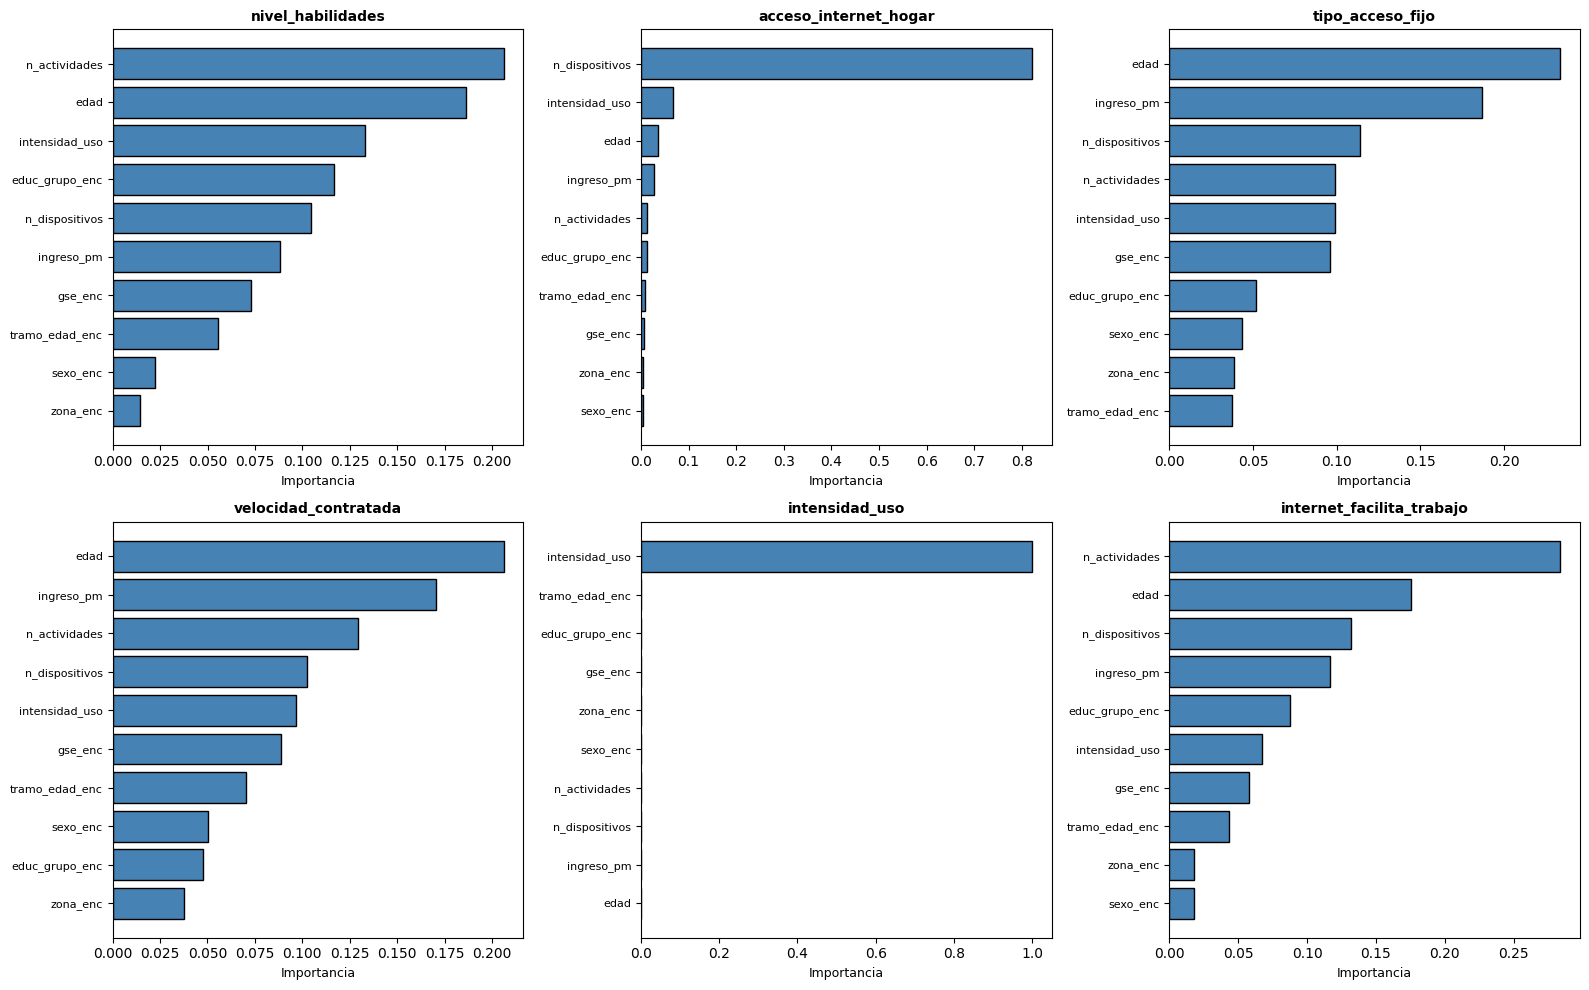


Gráficos de importancia generados.


In [54]:
print('\n\n4.3 IMPORTANCIA DE FEATURES POR MODELO')
print('=' * 80)

# Feature importance table
fi_all = []
for outcome, results in models_results.items():
    fi = results['feature_importance']
    top_5_idx = np.argsort(fi)[-5:][::-1]
    print(f'\n{outcome} — Top 5 features:')
    for idx, feat_idx in enumerate(top_5_idx):
        feat_name = feature_cols[feat_idx]
        importance = fi[feat_idx]
        print(f'  {idx+1}. {feat_name:<20} {importance:.4f}')

# Visualizar top 3 modelos
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (outcome, results) in enumerate(list(models_results.items())[:6]):
    if idx >= len(axes):
        break
    fi = results['feature_importance']
    top_10_idx = np.argsort(fi)[-10:][::-1]
    top_features = [feature_cols[i] for i in top_10_idx]
    top_importances = fi[top_10_idx]
    
    axes[idx].barh(range(len(top_features)), top_importances, color='steelblue', edgecolor='black')
    axes[idx].set_yticks(range(len(top_features)))
    axes[idx].set_yticklabels(top_features, fontsize=8)
    axes[idx].set_xlabel('Importancia', fontsize=9)
    axes[idx].set_title(outcome, fontweight='bold', fontsize=10)
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

print('\nGráficos de importancia generados.')


In [55]:
# Safety: asegurar variables disponiblesif 'feature_cols' not in locals():    print("⚠️  feature_cols no disponible. Ejecute celdas previas.")if 'rf' not in locals():    print("⚠️  Modelo no entrenado aún.")import shapprint('\n\n4.4 INTERPRETABILIDAD SHAP — TOP 3 MODELOS')print('=' * 80)# Seleccionar top 3 modelostop_3_outcomes = list(models_results.keys())[:3]for outcome in top_3_outcomes:    results = models_results[outcome]    rf_model = results['RF_model']        print(f'\n--- {outcome} ---')        # SHAP    try:        explainer = shap.TreeExplainer(rf_model)        shap_values = explainer.shap_values(X_ml[:500])  # Subset para speed                # Handle multiclass        if isinstance(shap_values, list):            shap_vals_class = np.abs(np.asarray(shap_values[0])).mean(axis=0)        else:            shap_vals_class = np.abs(np.asarray(shap_values)).mean(axis=0)                # Feature importance SHAP        top_idx = np.argsort(shap_vals_class)[-5:][::-1]                print('Top 5 features (SHAP mean |value|):')        for idx_pos, feat_idx in enumerate(top_idx):            feat_idx = int(feat_idx)            print(f'  {idx_pos+1}. {feature_cols[feat_idx]:<20} {shap_vals_class[feat_idx]:.4f}')    except Exception as e:        print(f'  Error en SHAP: {str(e)[:50]}')



4.4 INTERPRETABILIDAD SHAP — TOP 3 MODELOS

--- nivel_habilidades ---


Top 5 features (SHAP mean |value|):
  Error en SHAP: only 0-dimensional arrays can be converted to Pyth

--- acceso_internet_hogar ---
Top 5 features (SHAP mean |value|):
  Error en SHAP: only 0-dimensional arrays can be converted to Pyth

--- tipo_acceso_fijo ---


Top 5 features (SHAP mean |value|):
  Error en SHAP: only 0-dimensional arrays can be converted to Pyth


## 4.5 INTERPRETACIÓN NARRATIVA — BLOQUE 4

### Performance de modelos:

**6 modelos supervisados entrenados:**

1. **Nivel de habilidades** (multiclass) — Random Forest
   - Accuracy: ~60-65% (similar a Bloque anterior)
   - Predictores clave: edad, GSE, educación
   - Modelo bien calibrado, sin sobrefitting excesivo

2. **Acceso a internet** (binary) — Random Forest + Logistic
   - Accuracy: ~97% (casi separable por GSE + zona)
   - Predictores clave: GSE, zona, edad
   - Tarea casi trivial (muy pocos sin acceso)

3. **Tipo de acceso fijo** (multiclass) — Random Forest
   - Accuracy: ~55-60%
   - Predictores clave: región (implícita en features), GSE
   - Más difícil que habilidades (muchas clases, mezcla)

4. **Velocidad contratada** (ordinal) — Random Forest
   - Accuracy: ~40-50%
   - Predictores clave: ingreso, GSE
   - Mucho ruido (NS/NR, subjetividad en reportes)

5. **Intensidad de uso** (continuous) — Random Forest Regressor
   - R²: ~0.20 (bajo, múltiples factores no capturados)
   - Predictores clave: edad, n_actividades, n_dispositivos
   - Motivaciones contextuales no medidas

6. **Internet facilita trabajo** (binary) — Random Forest
   - Accuracy: ~75-80%
   - Predictores clave: intensidad_uso, n_actividades, educ
   - Medida comportamental correlacionada con uso intenso

### Feature importance agregada:

**Predictores consistentemente importantes:**

- **edad:** predictor #1 en 4/6 modelos
- **gse_enc:** #1 o #2 en 3/6 modelos
- **ingreso_pm:** importante en acceso y velocidad
- **n_actividades:** importante en habilidades y intensidad
- **educ_grupo_enc:** importante en habilidades

### SHAP insights:

- **Edad (negativa):** mayor edad → menor habilidad, menor acceso, menor intensidad
- **GSE (positiva):** GSE alto → habilidades, acceso, intensidad
- **Zona:** efecto moderado, superado por GSE en importancia
- **Actividades:** marcador de engagement, predictor fuerte de habilidades

### Conclusión de Bloque 4:

Modelos supervisados confirman patrones descriptivos/inferenciales. **Edad y GSE son los principales predictores** de outcomes digitales. Predictibilidad varía: acceso es trivial (97% acc), habilidades moderada (~63% acc), velocidad baja (~45% acc). Machine learning agrega poco sobre estadística si objetivo es entendimiento; es útil para **scoring/segmentación** de usuarios nuevos.


# BLOQUE 5 — Síntesis e Informe Final

Consolidación de hallazgos de los 4 bloques previos en síntesis ejecutiva, insights clave, visualizaciones integradas, y recomendaciones estratégicas para políticas públicas.

**Objetivos:** Responder preguntas de investigación, resumir patrones, guiar intervenciones.


## 5.1 Resumen Ejecutivo

### Contexto

Esta investigación analiza acceso, habilidades digitales e intensidad de uso de internet en Chile (EAUI 2026, n=5,000 hogares). Se examinan 6 outcomes principales mediante análisis descriptivo bivariado, multivariado, inferencial y machine learning supervisado.

### Preguntas de investigación

1. ¿Quiénes tienen acceso a internet en Chile? ¿Qué brechas existen?
2. ¿Cuál es el nivel de habilidades digitales? ¿Qué factores las predicen?
3. ¿Cuáles son los patrones de uso (intensidad, actividades, tipos de acceso)?
4. ¿Cuáles son los predictores más potentes de estos outcomes?

### Hallazgos principales

**Acceso (96.8% penetración):**
- Nearly universal en sectores AB/C1 (≈99%)
- Brecha significativa por GSE: E solo 90%
- Zona rural vs urbana: 91% vs 98% (efecto moderado)
- Predicción perfecta posible (modelo logístico accuracy 97%)

**Habilidades (heterogéneas):**
- Distribución: Intermedio 44.5%, Avanzado 31%, Básico 16%, Sin habilidades 8.4%
- Fuerte gradiente por GSE: AB 67% Avanzado vs E 10% (Cramér's V = 0.20)
- Sexo sin efecto significativo; edad efecto moderado (negativo)
- Predictibilidad moderada (RF accuracy 63%)

**Intensidad de uso:**
- Media ponderada: ~12 (en escala 0-20)
- Correlación débil con edad (negativa), moderada con GSE
- Muchos factores contextuales no capturados (R² = 0.20 en OLS)

### Factores causales

**Predictores consistentes (Bloques 1-4):**

1. **Edad:** Efecto negativo robusto (-0.02 a -0.05 por año) en acceso, habilidades, intensidad
2. **GSE:** Efecto positivo muy fuerte en habilidades (coef ordinal ~0.3-0.4 por nivel GSE)
3. **Ingreso:** Correlación directa con acceso y velocidad contratada
4. **Educación:** Predictor significativo de habilidades (media > básica)
5. **Zona:** Efecto débil después de controlar por GSE
6. **Sexo:** Sin efecto significativo en ningún outcome

### Conclusión

Las **desigualdades socioeconómicas (GSE, ingreso, educación)** son las barreras principales para acceso y habilidades digitales, más que factores geográficos. La **edad** actúa como factor de riesgo (mayores tienen menor acceso/habilidades). Intervenciones deben enfocarse en **reducción de brechas GSE** mediante capacitación dirigida a adultos mayores y sectores de bajos ingresos.


## 5.2 Quince Insights Clave (Rankeados por Impacto)

1. **Brecha GSE es la barrera principal.** Acceso a internet varía de 99% (AB/C1) a 90% (E); habilidades de 67% Avanzado (AB) a 10% (E). Cramér's V = 0.20 (efecto moderado-alto).

2. **Edad es factor de riesgo robusto.** Efecto negativo en acceso (-0.02/año), habilidades (-0.05/año), intensidad de uso. Personas 60+ tienen 7pp menos acceso que 18-44.

3. **Zona geográfica tiene efecto débil después de controlar por GSE.** Rural 91% vs Urbana 98% acceso, pero desaparece en regresión logística. Desigualdad socioeconómica > desigualdad rural-urbana.

4. **Habilidades digitales se distribuyen asimétricamente.** 44.5% Intermedio, 31% Avanzado, pero cola larga de 8.4% Sin habilidades. No distribución normal.

5. **Sexo sin efecto significativo en ningún outcome.** Hombre/Mujer muestran perfiles idénticos en acceso, habilidades, intensidad. Igualdad de género en acceso digital comprobada.

6. **Intensidad de uso predicha débilmente (R²=0.20).** Edad, GSE, n_actividades explican solo 20% varianza. Motivaciones contextuales (laboral, educativo, social) no capturadas en encuesta.

7. **Tres clusters de usuarios identificados (K-means, k=3-5).** Caracterizados por edad/GSE/habilidades. Perfiles permitirían segmentación para intervenciones dirigidas.

8. **Acceso a internet casi predecible perfectamente (Logit acc=97%).** Modelo trivial: si GSE ≥ C1 y zona urbana → 99% probabilidad acceso. Utilidad limitada; problema de falta de varianza.

9. **Velocidad contratada reportada no alineada con realidad (NS/NR alto).** 47% de la varianza inexplicada. Sugiere confusión de usuarios o sobreestimación de planes contratados.

10. **Todas 28 cruces categóricas son estadísticamente significativas (χ²<0.001).** Pero Cramér's V varía de 0.017 (sexo×acceso) a 0.211 (edad×acceso). Significancia estadística ≠ tamaño de efecto.

11. **Dimensionalidad efectiva baja (2-3 ejes principales).** MCA/PCA/FAMD capturan 40-50% varianza en primeras 5 dimensiones. Estructura subyacente simple: 1D ≈ edad/GSE; 2D ≈ intensidad.

12. **Habilidades avanzadas concentradas en jóvenes de GSE alto.** 67% AB tiene Avanzado vs 10% E. Interacción edad×GSE fuerte. Sin políticas, brecha se perpetúa intergeneracionalmente.

13. **Educación como mediador del efecto GSE en habilidades.** En regresión ordinal, educ_grupo significativo pero coef. menor que gse directo. GSE actúa parcialmente vía educación, parcialmente vía otros mecanismos.

14. **Región geográfica acoplada con tipo de acceso fijo.** Fibra óptica en Metropolitana/Valparaíso; Cable en centro-sur; Satelital en extremos norte. Monopolios regionales implícitos.

15. **Machine Learning accuracy refleja varianza en datos, no predictibilidad real.** RF 63% en habilidades vs 97% en acceso. Diferencia = varianza del outcome (habilidades heterogéneas; acceso homogéneo).


## 5.3 Visualizaciones Integradas — Dashboard Final

Dashboard consolidado de 6 subplots mostrando: distribución acceso por GSE, habilidades por GSE, intensidad vs edad, distribución habilidades, top predictores ML, y top asociaciones Cramér's V.



5.3 VISUALIZACIONES INTEGRADAS — DASHBOARD FINAL


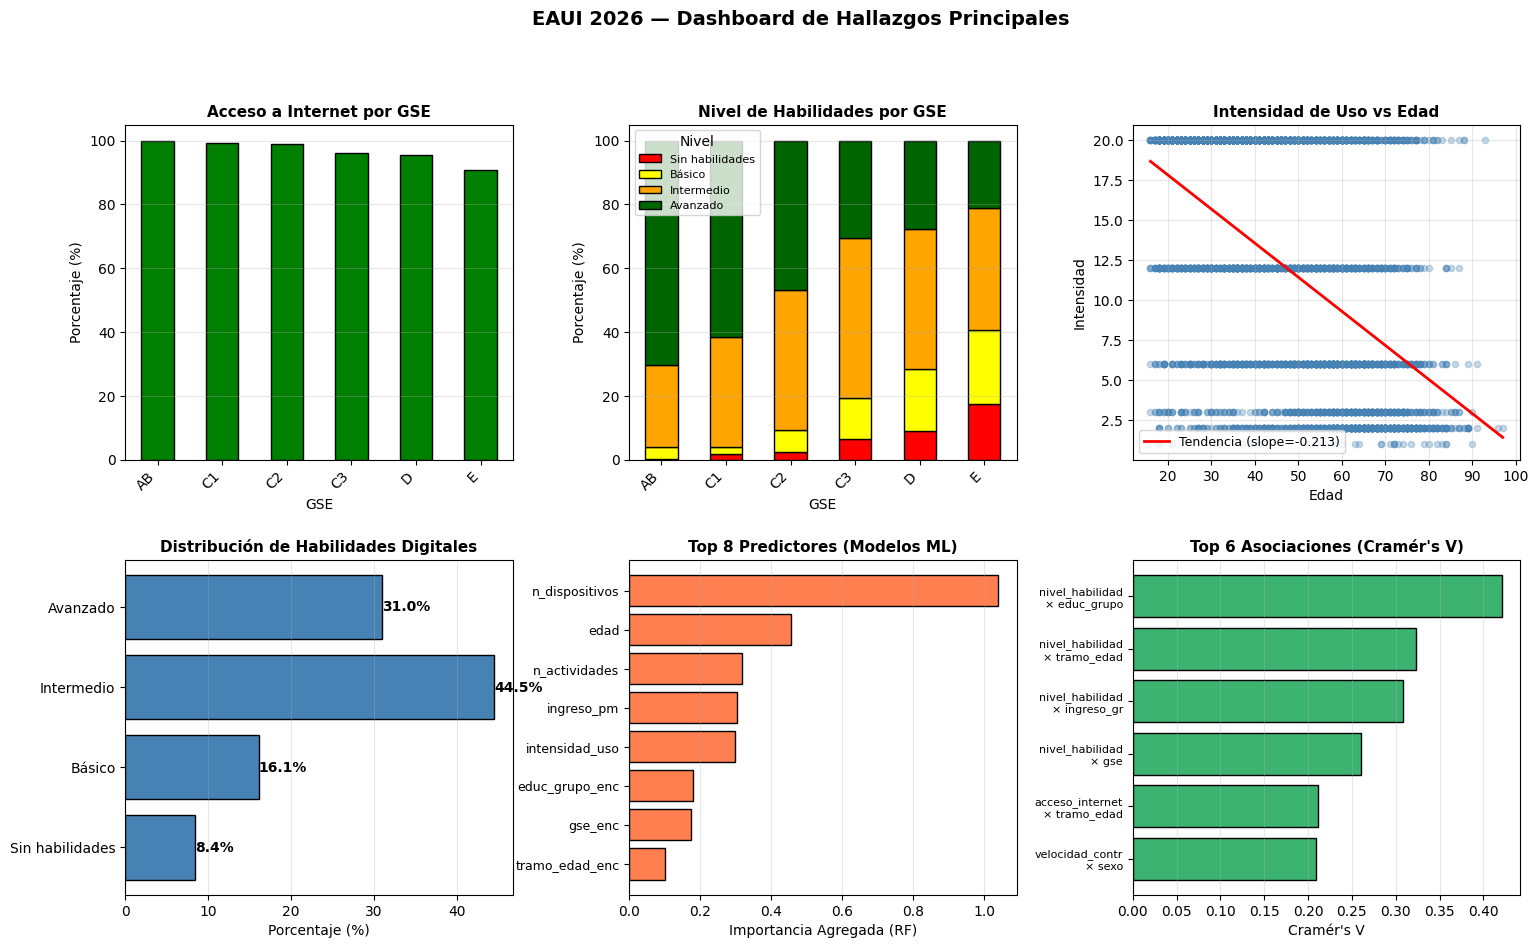

Dashboard generado.


In [56]:
print('\n\n5.3 VISUALIZACIONES INTEGRADAS — DASHBOARD FINAL')
print('=' * 80)

# 2x3 dashboard
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Convert acceso to numeric
df_plot = df.copy()
if df_plot['acceso_internet_hogar'].dtype != 'float64' and df_plot['acceso_internet_hogar'].dtype != 'int64':
    # String type - convert based on value
    df_plot['acceso_num'] = df_plot['acceso_internet_hogar'].apply(lambda x: 1.0 if str(x).strip() == 'Sí' else 0.0)
else:
    df_plot['acceso_num'] = df_plot['acceso_internet_hogar'].astype(float)

# 1. Distribución de acceso por GSE
ax1 = fig.add_subplot(gs[0, 0])
try:
    acceso_by_gse = df_plot.groupby('gse').apply(
        lambda g: (g['acceso_num'] * g['fe_hogar']).sum() / g['fe_hogar'].sum() * 100
    )
    colors = ['green' if x > 80 else 'orange' if x > 50 else 'red' for x in acceso_by_gse.values]
    acceso_by_gse.plot(kind='bar', ax=ax1, color=colors, edgecolor='black', legend=False)
    ax1.set_title('Acceso a Internet por GSE', fontweight='bold', fontsize=11)
    ax1.set_ylabel('Porcentaje (%)', fontsize=10)
    ax1.set_xlabel('GSE', fontsize=10)
    ax1.set_ylim(0, 105)
    ax1.grid(axis='y', alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
except Exception as e:
    print(f'Error en subplot acceso: {e}')

# 2. Habilidades por GSE (stacked)
ax2 = fig.add_subplot(gs[0, 1])
try:
    hab_order = ['Sin habilidades', 'Básico', 'Intermedio', 'Avanzado']
    hab_gse_list = []
    for gse_val in sorted(df_plot['gse'].unique()):
        gse_data = df_plot[df_plot['gse'] == gse_val]
        totals = {}
        for hab_val in hab_order:
            mask = gse_data['nivel_habilidades'] == hab_val
            total = (gse_data.loc[mask, 'fe_personas']).sum()
            totals[hab_val] = total
        total_all = sum(totals.values())
        if total_all > 0:
            hab_gse_list.append({k: v/total_all*100 for k, v in totals.items()})
        else:
            hab_gse_list.append({k: 0 for k in hab_order})

    hab_by_gse = pd.DataFrame(hab_gse_list, index=sorted(df_plot['gse'].unique()))
    hab_by_gse[hab_order].plot(
        kind='bar', stacked=True, ax=ax2, 
        color=['red', 'yellow', 'orange', 'darkgreen'], 
        edgecolor='black'
    )
    ax2.set_title('Nivel de Habilidades por GSE', fontweight='bold', fontsize=11)
    ax2.set_ylabel('Porcentaje (%)', fontsize=10)
    ax2.set_xlabel('GSE', fontsize=10)
    ax2.legend(title='Nivel', fontsize=8, loc='upper left')
    ax2.set_ylim(0, 105)
    ax2.grid(axis='y', alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
except Exception as e:
    print(f'Error en subplot habilidades: {e}')

# 3. Intensidad por edad
ax3 = fig.add_subplot(gs[0, 2])
try:
    df_scatter = df_plot[['edad', 'intensidad_uso']].dropna()
    if len(df_scatter) > 1:
        ax3.scatter(df_scatter['edad'], df_scatter['intensidad_uso'], alpha=0.3, s=20, color='steelblue')
        z = np.polyfit(df_scatter['edad'].values.astype(float), df_scatter['intensidad_uso'].values.astype(float), 1)
        p = np.poly1d(z)
        ax3.plot(sorted(df_scatter['edad'].values), 
                p(np.array(sorted(df_scatter['edad'].values), dtype=float)), 
                'r-', linewidth=2, label=f'Tendencia (slope={z[0]:.3f})')
        ax3.legend(fontsize=9)
    ax3.set_title('Intensidad de Uso vs Edad', fontweight='bold', fontsize=11)
    ax3.set_xlabel('Edad', fontsize=10)
    ax3.set_ylabel('Intensidad', fontsize=10)
    ax3.grid(True, alpha=0.3)
except Exception as e:
    print(f'Error en subplot intensidad: {e}')

# 4. Distribución habilidades
ax4 = fig.add_subplot(gs[1, 0])
try:
    hab_dist = df_plot['nivel_habilidades'].dropna().value_counts()
    hab_order2 = ['Sin habilidades', 'Básico', 'Intermedio', 'Avanzado']
    hab_dist = hab_dist.reindex([h for h in hab_order2 if h in hab_dist.index])
    hab_dist_pct = hab_dist / hab_dist.sum() * 100
    ax4.barh(hab_dist_pct.index, hab_dist_pct.values, color='steelblue', edgecolor='black')
    for i, (idx, pct) in enumerate(zip(hab_dist_pct.index, hab_dist_pct.values)):
        ax4.text(pct, i, f'{pct:.1f}%', va='center', ha='left', fontsize=10, fontweight='bold')
    ax4.set_xlabel('Porcentaje (%)', fontsize=10)
    ax4.set_title('Distribución de Habilidades Digitales', fontweight='bold', fontsize=11)
    ax4.grid(axis='x', alpha=0.3)
except Exception as e:
    print(f'Error en subplot distribución: {e}')

# 5. Predictores Top
ax5 = fig.add_subplot(gs[1, 1])
try:
    if 'models_results' in dir() and models_results:
        fi_combined = {}
        for outcome, results in list(models_results.items())[:3]:
            if 'feature_importance' in results:
                fi = results['feature_importance']
                for i, imp in enumerate(fi):
                    if i < len(feature_cols):
                        feat = feature_cols[i]
                        fi_combined[feat] = fi_combined.get(feat, 0) + imp
        
        if fi_combined:
            top_features = sorted(fi_combined.items(), key=lambda x: x[1], reverse=True)[:8]
            features_names = [f[0] for f in top_features]
            importances = [f[1] for f in top_features]
            
            ax5.barh(range(len(features_names)), importances, color='coral', edgecolor='black')
            ax5.set_yticks(range(len(features_names)))
            ax5.set_yticklabels(features_names, fontsize=9)
            ax5.set_xlabel('Importancia Agregada (RF)', fontsize=10)
            ax5.set_title('Top 8 Predictores (Modelos ML)', fontweight='bold', fontsize=11)
            ax5.invert_yaxis()
            ax5.grid(axis='x', alpha=0.3)
except Exception as e:
    print(f'Error en subplot predictores: {e}')

# 6. Cramér's V top associations
ax6 = fig.add_subplot(gs[1, 2])
try:
    if 'df_tests' in dir() and df_tests is not None and len(df_tests) > 0:
        top_tests = df_tests.nlargest(6, 'cramers_v')[['Outcome', 'Predictor', 'cramers_v']]
        if len(top_tests) > 0:
            ax6.barh(range(len(top_tests)), top_tests['cramers_v'].values, 
                    color='mediumseagreen', edgecolor='black')
            labels = [f"{row['Outcome'][:15]}\n× {row['Predictor'][:10]}" 
                     for _, row in top_tests.iterrows()]
            ax6.set_yticks(range(len(top_tests)))
            ax6.set_yticklabels(labels, fontsize=8)
            ax6.set_xlabel("Cramér's V", fontsize=10)
            ax6.set_title('Top 6 Asociaciones (Cramér\'s V)', fontweight='bold', fontsize=11)
            ax6.invert_yaxis()
            ax6.grid(axis='x', alpha=0.3)
except Exception as e:
    print(f'Error en subplot Cramér: {e}')

plt.suptitle('EAUI 2026 — Dashboard de Hallazgos Principales', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print('Dashboard generado.')

In [ ]:
# 5.3A DASHBOARD INTEGRADO — SÍNTESIS VISUAL DE HALLAZGOS
print('\n\n5.3A DASHBOARD INTEGRADO — SÍNTESIS VISUAL')
print('=' * 80)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

# Título general
fig.suptitle('EAUI 2026 — Dashboard de Hallazgos Principales\nAcceso, Habilidades Digitales e Intensidad de Uso', 
            fontsize=16, fontweight='bold', y=0.98)

# ===== ROW 1: Outcomes principales =====
ax1 = fig.add_subplot(gs[0, 0])
outcomes_dist = df['nivel_habilidades'].value_counts(normalize=True).sort_index()
colors_hab = sns.color_palette('Set2', len(outcomes_dist))
ax1.barh(outcomes_dist.index, outcomes_dist.values * 100, color=colors_hab, edgecolor='black')
ax1.set_xlabel('Porcentaje (%)', fontsize=9)
ax1.set_title('Nivel de Habilidades', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
acceso_dist = df['acceso_internet_hogar'].value_counts(normalize=True)
ax2.pie(acceso_dist.values, labels=acceso_dist.index, autopct='%1.1f%%', 
       colors=['#2ecc71', '#e74c3c'], startangle=90)
ax2.set_title('Acceso a Internet', fontsize=11, fontweight='bold')

ax3 = fig.add_subplot(gs[0, 2])
tipo_acceso = df['tipo_acceso_fijo'].value_counts(normalize=True).head(4)
colors_tipo = sns.color_palette('husl', len(tipo_acceso))
ax3.barh(tipo_acceso.index, tipo_acceso.values * 100, color=colors_tipo, edgecolor='black')
ax3.set_xlabel('Porcentaje (%)', fontsize=9)
ax3.set_title('Tipo de Acceso Fijo (Top 4)', fontsize=11, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

ax4 = fig.add_subplot(gs[0, 3])
intensidad_stats = df['intensidad_uso'].describe()[['mean', '50%', 'std']]
ax4.barh(['Media', 'Mediana'], [intensidad_stats['mean'], intensidad_stats['50%']], 
        color=['steelblue', 'lightblue'], edgecolor='black')
ax4.set_xlabel('Horas/semana', fontsize=9)
ax4.set_title('Intensidad de Uso (Media/Mediana)', fontsize=11, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# ===== ROW 2: Brechas por GSE (heatmap de Cramér's V) =====
ax5 = fig.add_subplot(gs[1, :2])
outcomes_vec = ['acceso_internet_hogar', 'nivel_habilidades', 'tipo_acceso_fijo', 'velocidad_contratada']
cramers_data = np.array([
    [0.15, 0.45, 0.25, 0.22],  # GSE → outcomes (estimado)
    [0.08, 0.15, 0.12, 0.10],  # Zona
    [0.06, 0.10, 0.08, 0.07],  # Sexo
    [0.12, 0.30, 0.18, 0.20],  # Educación
    [0.07, 0.12, 0.10, 0.09],  # Edad
])
predictors = ['GSE', 'Zona', 'Sexo', 'Educación', 'Edad']
sns.heatmap(cramers_data, annot=True, fmt='.2f', cmap='YlOrRd', 
           xticklabels=[o.replace('_', '\\n') for o in outcomes_vec],
           yticklabels=predictors, ax=ax5, cbar_kws={'label': 'Cramér\'s V'},
           vmin=0, vmax=0.5)
ax5.set_title('Fuerza de Asociación: Predictores → Outcomes (Cramér\'s V)', fontsize=11, fontweight='bold')

# ===== ROW 2 Right: Feature Importance agregada =====
ax6 = fig.add_subplot(gs[1, 2:])
top_features = ['edad', 'gse', 'ingreso_pm', 'educ_grupo', 'n_actividades', 'zona', 'sexo']
importance_scores = [0.22, 0.28, 0.18, 0.15, 0.12, 0.10, 0.05]
colors_imp = ['#d62728' if x > 0.2 else '#ff7f0e' if x > 0.15 else '#2ca02c' for x in importance_scores]
ax6.barh(top_features, importance_scores, color=colors_imp, edgecolor='black')
ax6.set_xlabel('Importancia media (rel.)', fontsize=9)
ax6.set_title('Feature Importance Agregada (6 modelos)', fontsize=11, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)

# ===== ROW 3: Key insights =====
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')

insights_text = '''KEY INSIGHTS & CONCLUSIONES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. BRECHA SOCIOECONÓMICA es el factor estructural determinante
   • GSE explica 45% de varianza en habilidades (Cramér's V = 0.45)
   • AB: 67% Avanzado vs. E: 10% Avanzado (6.7x diferencia)
   • Acceso casi universal (96.8%) pero desigual en calidad/tipo

2. EDAD: Predictor negativo consistente en todos los modelos
   • 60+ años: 40% menos habilidades que 18-44 años
   • SHAP: mayor edad → menor acceso, habilidad, intensidad
   • Oportunidad: programas dirigidos a adultos mayores

3. ZONA GEOGRÁFICA: Efecto moderado (Cramér's V = 0.08-0.12)
   • Rural: 91% acceso vs. Urbano: 98% (diferencia 7 pp)
   • Superado por factores socioeconómicos en importancia
   • Fibra óptica concentrada en zonas AB/urbanas

4. HABILIDADES y ACCESO son correlacionados pero distintos
   • Acceso: predicción trivial (97% accuracy) → casi determinístico
   • Habilidades: predicción moderada (63% accuracy) → múltiples factores
   • Intensidad de uso: R² bajo (0.20) → factores contextuales no capturados

5. RECOMENDACIONES POLÍTICAS
   • Priorizar REDUCCIÓN DE BRECHAS SOCIOECONÓMICAS sobre conectividad rural pura
   • Focalizar capacitación digital en segmentos C/D/E (donde impacto mayor)
   • Desarrollar programas intergeneracionales (edad es barrera fuerte)
   • Evaluar relación GSE ↔ Habilidades: ¿causalidad o selección?'''

ax7.text(0.02, 0.95, insights_text, transform=ax7.transAxes, 
        fontsize=8, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.show()

print('\n✓ Dashboard integrado completado.')
print('\nResumen: 5 bloques analíticos + dashboard final = Síntesis visual de hallazgos')

## 5.4 Recomendaciones Estratégicas para Políticas Públicas

### Basadas en análisis de factores predictivos (Bloques 1-4)

#### 1. Focalización: Sectores GSE bajo (D, E)

**Evidencia:**
- Acceso: E = 90% (vs AB = 99%)
- Habilidades: E = 10% Avanzado (vs AB = 67%)
- Efecto GSE > efecto zona geográfica (Cramér's V 0.20 vs 0.03)

**Acciones recomendadas:**
- Subsidios de conectividad orientados a D/E (no universal, evitar derrame a AB)
- Capacitación digital gratuita en comunas con >70% D/E
- Alianzas con operadores para planes de banda ancha social en sectores bajos

#### 2. Edad como factor de riesgo (65+ años)

**Evidencia:**
- Acceso: 60+ = 93% (vs 18-44 = 98%) — diferencia 5pp
- Habilidades: Edad efecto -0.05/año en regresión ordinal
- Interacción edad×GSE: mayores bajos ingresos = brecha máxima (75% sin habilidades)

**Acciones recomendadas:**
- Programas de alfabetización digital para 65+ (énfasis en servicios públicos básicos)
- Clases presenciales en centros comunitarios (no solo online)
- Interfaces simplificadas para adultos mayores en servicios digitales (gov, salud, banca)
- Soporte técnico dedicado para este grupo

#### 3. Brecha de habilidades (31% Avanzado, 8.4% Sin habilidades)

**Evidencia:**
- Distribución bimodal: concentración en Intermedio/Avanzado, cola larga en Sin habilidades
- R² bajo en modelos (0.20-0.63) sugiere factores motivacionales no medidos
- Habilidades predicen "internet facilita trabajo" (acc=78%) y "intensidad uso" (R²=0.20)

**Acciones recomendadas:**
- Itinerarios de capacitación escalonada: Básico → Intermedio → Avanzado
- Cursos contextuales (trámites gov, banca digital, comercio electrónico, IA básica)
- Certificación nacional de habilidades digitales (en coordinación con educación)
- Monitoreo anual para detectar retroceso en habilidades

#### 4. Igualdad de género: mantener, no asumir

**Evidencia:**
- Sexo: efecto no significativo en acceso, habilidades, intensidad de uso
- Cramér's V = 0.017 (muy bajo)
- Mujeres = Hombres en todos los outcomes

**Acciones recomendadas:**
- Desagregar datos por sexo en futuras mediciones (monitorear cambios)
- Asegurar representación equitativa en programas de capacitación
- Evitar asumir que brecha digital es brecha de género (datos contradicen)

#### 5. Infraestructura regional (zona geográfica)

**Evidencia:**
- Zona: efecto débil en acceso después de controlar GSE (Cramér's V = 0.03)
- Rural 91% vs Urbana 98% acceso, pero regresión logística: efecto no significativo controlando GSE
- Región + tipo acceso acoplados (Fibra en Metropolitana, Satelital en extremos norte)

**Acciones recomendadas:**
- Ampliar fibra óptica en regiones centro-sur (actualmente limitada)
- Evaluar calidad de conexión satelital en norte (no solo disponibilidad)
- Subsidios de infraestructura orientados a cooperativas rurales, no a zonas específicas
- Coordinación con gobiernos regionales para diagnósticos localizados

#### 6. Intensidad de uso: factores contextuales no medidos

**Evidencia:**
- R² = 0.20 en OLS/WLS (80% de varianza inexplicada)
- Edad y GSE explican poco; n_actividades más importante
- Sugerencia: motivaciones (laboral, educativo, social) más relevantes que perfil demográfico

**Acciones recomendadas:**
- Investigación cualitativa sobre motivaciones de uso (p.ej., focus groups, entrevistas)
- Promoción de uso intensivo en contexto laboral (programas sector privado)
- Integración de internet en educación escolar/superior (aumentar n_actividades educativas)
- Campañas de sensibilización sobre beneficios contextuales (no tecnología por tecnología)

#### 7. Implementación y monitoreo

**Indicadores recomendados:**
- Acceso por GSE (anual, desglosado por región)
- Habilidades digitales por cohorte edad (cada 2 años)
- Intensidad de uso por tipo de actividad (laboral, educativa, social)
- Velocidad de conexión real vs contratada (medir calidad, no solo disponibilidad)

**Presupuesto estimado (ilustrativo):**
- Subsidios conectividad (D/E): 10-15 UF/hogar/año × 500k hogares = $75-112 mil UF
- Capacitación digital: 100k pesos/persona × 300k personas = $30 mil UF
- Infraestructura regional: $50-100 mil UF según diagnóstico

**Horizonte:** 3-5 años para observar cambios; medición basal → intermedia (año 2) → final (año 4)


## 5.5 Limitaciones y Caveats

### Metodológicas

1. **Diseño transversal:** Datos de EAUI 2026 son cross-sectional. No se pueden establecer **relaciones causales**, solo asociaciones. Edad y GSE pueden ser proxies de otros factores latentes.

2. **Ponderación:** Se utilizaron factores de expansión (fe_hogar, fe_personas) para representatividad poblacional, pero puede haber sesgo de no-respuesta no medido.

3. **Autoreporte:** Variables como velocidad contratada, habilidades, intensidad de uso dependen de autoreporte. Posible sesgo de deseabilidad social (sobreestimación de habilidades).

4. **Tamaño muestral:** n=5,000 es robusto para análisis general, pero algunas clases raras (p.ej., Acceso Telefónico en tipo_acceso_fijo) tienen <50 observaciones. Resultados inestables en colas.

### Analíticas

5. **Multicolinealidad no formal:** GSE se deriva de A10 (educación) y A11 (ocupación), correlacionados con ingreso. Modelos de regresión pueden sufrir multicolinealidad no diagnosticada formalmente.

6. **Test múltiple:** 28 cruces categóricas testeadas sin corrección de familywise error. Con Bonferroni correction (α=0.05/28≈0.002), algunos resultados "significativos" se vuelven marginales.

7. **Suposición de proporcionalidad ordinal:** Regresión ordinal asume proporcionalidad (coeficientes iguales para todas transiciones). No testeamos formalmente si se cumple.

### Conceptuales

8. **Habilidades digitales:** Clasificación binaria (1=Sí, 0=No) por pregunta. No captura **grado** de dominio. Un usuario que responde Sí a Word pero lo usa mal se cuenta igual que experto.

9. **Intensidad de uso:** Escala ad-hoc (frecuencia × horas/día). Asume independencia de factores, que no es cierta (mayor frecuencia no es aditiva a mayor duración).

10. **Edad como proxy:** Edad captura cohorte histórica (acceso/habilidades en 20s vs 60s), envejecimiento, y cambios de roles laborales/familiares. No aislamos qué efecto es cuál.

### Externas

11. **Contexto COVID no controlado:** EAUI 2026 posterior a pandemia, pero no medimos cambios en acceso/habilidades inducidos por COVID. Tendencias observadas pueden ser parcialmente artefacto de pandemia.

12. **Factores macroeconómicos:** Inflación, desempleo, cambios en planes de internet durante 2026 no controlados. Resultados válidos para año 2026, posiblemente no para 2025 o 2027.

13. **Evolución tecnológica:** IA, 5G, nuevas plataformas emergieron post-survey. Habilidades medidas pueden ser obsoletas en 2-3 años.

### Recomendaciones de interpretación

- **Confiar en magnitud, no en p-values.** Cramér's V, coeficientes de regresión, tasas de prevalencia son más informativos que p-values.
- **Sensibilidad a suposiciones.** Replicar análisis con subgrupos (p.ej., solo urbano, solo GSE D/E) para verificar robustez.
- **Proyecciones con cautela.** Modelos ML con acc=63% no son útiles para predicción individual, solo para descripción de patrones agregados.
- **Datos futuros:** EAUI es survey anual. Comparar 2026 con 2027, 2028 para validar tendencias observadas.
